# Imports

In [1]:
import time

# Start execution timing
start_time = time.time()


import glob
import os

import copy
from datetime import datetime

import warnings

import numpy as np
import numba
from numba import njit
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from hmmlearn import hmm

from scipy.cluster.hierarchy import linkage, to_tree

from xgboost import XGBRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import root_mean_squared_error,r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Initial Configurations

In [2]:
global HOME_DIR
HOME_DIR = '/kaggle'

global output_folder_path
output_folder_path = ''
if not os.path.exists(HOME_DIR):
    HOME_DIR = '../../kaggle'
    output_folder_path = HOME_DIR + '/output/competitions/rogii-wellbore-geology-prediction/'
print(os.path.exists(HOME_DIR))

input_folder_path = HOME_DIR + '/input/competitions/rogii-wellbore-geology-prediction/'

global working_folder_path
working_folder_path = HOME_DIR + '/working/'

global SEED
SEED = 42

# Validation step switch
VALIDATION = True

# Look-ahead to perform calculations, including on horizontal test wells
LOOK_AHEAD = True

# Set numpy random seed
np.random.seed(SEED)

global rng
rng = np.random.default_rng(seed=SEED)

# For seed-based reproducibility in torch we create a "generator"
global g
g = torch.Generator()
g.manual_seed(SEED)

global device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set pytorch random seed
torch.manual_seed(SEED)          # covers tensor ops, weight init
torch.cuda.manual_seed(SEED)     # covers GPU ops

# Disable all warnings
warnings.filterwarnings("ignore")

# Configure Pandas to show full content
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

True


# Functions

#### EDA Functions

In [3]:
def get_typewell_TVT_diffs(df_v, nb_rows):
    """Function to check the smallest and largest differences in TVT on typewells"""

    tvtdiff_dfs = []
    for well, df_well in df_v[['wellname','TVT']].groupby('wellname', sort=False):
        df_current = df_well.copy()
        df_current['TVT_diff'] = df_current['TVT'].diff().round(2)
        tvtdiff_dfs.append(df_current)

    df_v_tvtdiff = pd.concat(tvtdiff_dfs, axis=0, sort=False, ignore_index=True)
    df_v_tvtdiff = df_v_tvtdiff.groupby('wellname').agg(diff_min=('TVT_diff', 'min'), diff_max=('TVT_diff', 'max')).round(2)
    print('Typewell TVT diffs:', df_v_tvtdiff.sort_values('diff_max', ascending=False).head(nb_rows))

In [4]:
def get_TVT_to_TVD_diffs(df_h, nb_rows):
    """Function to check the largest differences between each well's last record TVT and TVD"""

    df_h_tvtdiff = df_h.copy()
    df_h_tvtdiff['TVT_diff'] = (df_h_tvtdiff['TVT'] - df_h_tvtdiff['TVD']).round(2)
    idx = df_h_tvtdiff.groupby('wellname')['TVT_diff'].idxmax()
    print('TVT diffs:', df_h_tvtdiff.loc[idx, ['wellname', 'TVD', 'TVT', 'TVT_diff']].sort_values('TVT_diff', ascending=False).head(nb_rows))

#### Preprocessing and Cleanup Functions

In [5]:
def check_missingwells(df_h, df_v):
    """Check if well exists both in horizontal and typewell"""
    wells_df_h = set(df_h["wellname"].unique())
    wells_df_v = set(df_v["wellname"].unique())

    only_df_h = wells_df_h - wells_df_v
    only_df_v = wells_df_v - wells_df_h

    if len(only_df_h) > 0 or len(only_df_v) > 0:
        print("Only in df_h:")
        print(sorted(only_df_h))
        print("\nOnly in df_v:")
        print(sorted(only_df_v))
        raise ValueError('At least one well file is missing!!!')
    else:
        print("No well files missing.")

In [6]:
@njit(cache=False)
def _ols_regression(x: np.ndarray, y: np.ndarray):
    """Fits an ordinary least squares regression"""
    sample_size = len(x)
    if sample_size == 1:
        return 0.0, y[0], 0.0

    # Calculate means
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Calculate sum of squares
    ss_xx = 0.0
    ss_xy = 0.0
    for i in range(sample_size):
        dx = x[i] - mean_x
        dy = y[i] - mean_y
        ss_xx += dx * dx
        ss_xy += dx * dy

    if ss_xx == 0.0:
        # If x is constant, slope is undefined or 0, intercept is mean_y. Residuals are just (y - mean_y)
        rss = 0.0
        for i in range(sample_size):
            diff = y[i] - mean_y
            rss += diff * diff
        std_err = np.sqrt(rss / (sample_size - 1)) if sample_size > 1 else 0.0
        return 0.0, mean_y, std_err

    slope = ss_xy / ss_xx
    intercept = mean_y - slope * mean_x

    # Calculate Residual Sum of Squares (RSS)
    rss = 0.0
    for i in range(sample_size):
        predicted = slope * x[i] + intercept
        residual = y[i] - predicted
        rss += residual * residual

    # Calculate standard error
    # Degrees of freedom: n - 2 (for slope and intercept)
    if sample_size > 2:
        variance = rss / (sample_size - 2)
        std_err = variance ** 0.5
    else:
        # Cannot estimate variance with less than 2 samples
        std_err = 0.0

    return slope, intercept, std_err


@njit(cache=False)
def _fill_computation(x_vals: np.ndarray, y_vals: np.ndarray, gap_starts, gap_ends, known_pos, look_ahead: bool, start_samples: int, middle_samples: int, end_samples: int, rng_arr: np.ndarray):
    """
    Fills values according to whether the gap is at the beginning of the sequence, middle, or end
    """

    def _get_next_value(rng_arr, i):
        """
        Returns the next standard normal number and next index
        """
        if i >= len(rng_arr):
            raise ValueError("Index out of bounds")

        value = rng_arr[i]
        return value, i + 1

    def _calculate_edge_preds(gap_start, gap_end, anc_y, i):
        # mean, std calc
        mean_y = np.mean(anc_y)
        std_y = np.std(anc_y)

        for pos in range(gap_start, gap_end + 1):
            z_score, i = _get_next_value(rng_arr, i)
            y_vals[pos] = mean_y + z_score * std_y

        return i

    # Length of dataset
    known_samples = len(known_pos)
    i=0

    # For each gap, we get the indices of starts and ends
    for gap in range(len(gap_starts)):
        gap_start = gap_starts[gap]
        gap_end = gap_ends[gap]

        # Counts of known positions before and after the gap
        samples_before = 0
        samples_after  = 0
        for k in range(known_samples):
            if known_pos[k] < gap_start:
                samples_before += 1
            elif known_pos[k] > gap_end:
                samples_after += 1

        is_leading  = (samples_before == 0)
        is_trailing = (samples_after  == 0)

        # Start of sequence section
        if is_leading:
            used_samples = min(start_samples, samples_after)
            anc_y = np.empty(used_samples, dtype=np.float64)
            count = 0
            for k in range(known_samples):
                if known_pos[k] > gap_end:
                    anc_y[count] = y_vals[known_pos[k]]
                    count += 1
                    if count == used_samples:
                        break
            i = _calculate_edge_preds(gap_start, gap_end, anc_y, i)

        # End of sequence section
        elif is_trailing:
            used_samples = min(end_samples, samples_before)
            anc_y = np.empty(used_samples, dtype=np.float64)
            count = 0
            # walk backwards through known_pos
            for k in range(known_samples - 1, -1, -1):
                if known_pos[k] < gap_start:
                    anc_y[count] = y_vals[known_pos[k]]
                    count += 1
                    if count == used_samples:
                        break
            i = _calculate_edge_preds(gap_start, gap_end, anc_y, i)

        # Middle of sequence section
        else:
            used_samples_each = middle_samples
            used_samples_before = min(used_samples_each, samples_before)

            if look_ahead:
                used_samples_after  = min(used_samples_each, samples_after)
                used_samples       = used_samples_before + used_samples_after

                anc_x = np.empty(used_samples, dtype=np.float64)
                anc_y = np.empty(used_samples, dtype=np.float64)

                count = 0
                collected = 0
                for k in range(known_samples - 1, -1, -1):
                    if known_pos[k] < gap_start:
                        anc_x[count] = x_vals[known_pos[k]]
                        anc_y[count] = y_vals[known_pos[k]]
                        count += 1
                        collected += 1
                        if collected == used_samples_before:
                            break

                collected = 0
                for k in range(known_samples):
                    if known_pos[k] > gap_end:
                        anc_x[count] = x_vals[known_pos[k]]
                        anc_y[count] = y_vals[known_pos[k]]
                        count += 1
                        collected += 1
                        if collected == used_samples_after:
                            break

                slope, intercept, std_error = _ols_regression(anc_x[:count], anc_y[:count])

                for pos in range(gap_start, gap_end + 1):
                    predicted = intercept + slope * x_vals[pos]
                    z_score, i = _get_next_value(rng_arr, i)
                    y_vals[pos] = predicted + z_score * std_error

            # If filling without looking ahead
            else:
                used_samples = used_samples_before
                anc_y = np.empty(used_samples, dtype=np.float64)
                count = 0
                # walk backwards through known_pos
                for k in range(known_samples - 1, -1, -1):
                    if known_pos[k] < gap_start:
                        anc_y[count] = y_vals[known_pos[k]]
                        count += 1
                        if count == used_samples:
                            break
                i = _calculate_edge_preds(gap_start, gap_end, anc_y, i)



def fill_gr_nan(df: pd.DataFrame, col_y: str, col_x: str, look_ahead: bool = True, start_samples: int = 3, middle_edge_samples: int = 2, end_samples: int = 3, zscore_cap: float = 1.0) -> pd.DataFrame:
    """
    Function to fill NaN values on the horizontal wells
    """
    if df[col_x].isna().any():
        raise ValueError(f"Predictor column '{col_x}' must not contain NaNs.")

    missing_mask = df[col_y].isna().to_numpy()

    if not missing_mask.any():
        return df

    # Conversion to numpy arrays
    x_arr = df[col_x].to_numpy(dtype=np.float64)
    y_arr = df[col_y].to_numpy(dtype=np.float64).copy()

    # Generate std normal dist random number prior to numba, discarding random zscores outside boundaries
    target_count = len(np.where(missing_mask)[0])
    allowed_zscores = []
    if zscore_cap == 0:
        rng_arr = np.zeros(target_count, dtype=np.float64)
    else:
        while len(allowed_zscores) < target_count:
            rand_zscores = rng.standard_normal()
            if abs(rand_zscores) <= zscore_cap:
                allowed_zscores.append(rand_zscores)
        rng_arr = np.array(allowed_zscores, dtype=np.float64)

    # Detection of gap blocks
    padded   = np.concatenate([[False], missing_mask, [False]])
    gap_starts   = np.where(~padded[:-1] &  padded[1:])[0]
    gap_ends     = np.where( padded[:-1] & ~padded[1:])[0] - 1

    # array with only the indices of known positions ([0] here is to exit np.where tuple and return the array)
    known_pos = np.where(~missing_mask)[0].astype(np.int64)

    _fill_computation(x_arr, y_arr, gap_starts, gap_ends, known_pos, look_ahead, int(start_samples), int(middle_edge_samples), int(end_samples), rng_arr)

    df[col_y] = y_arr
    df[col_y] = df[col_y].round(2)

In [7]:
@njit(cache=False)
def _fill_layer_computation(col_arr, gap_starts, gap_ends, non_na_indices, non_na_values, look_ahead):

    for start, end in zip(gap_starts, gap_ends):
        # Identifying the nearest non-NA values surrounding this gap
        # Find index in non_na_indices that is just before 'start'
        left_non_na_idx = np.searchsorted(non_na_indices, start, side='right') - 1
        # Find index in non_na_indices that is just after 'end'
        right_non_na_idx = np.searchsorted(non_na_indices, end, side='left')

        # Get the index and value, first handling edges
        if left_non_na_idx < 0:
            # Gap is at the very start, take the first available value
            value = non_na_values[right_non_na_idx]
            # Fill the whole gap
            col_arr[start:end+1] = value

        elif right_non_na_idx >= len(non_na_values) or look_ahead == False:
            # Gap is at the very end, take the last available value
            value = non_na_values[left_non_na_idx]
            col_arr[start:end+1] = value

        else:
            if look_ahead:
                # We have both left and right neighbors
                left_idx = non_na_indices[left_non_na_idx]
                left_val = non_na_values[left_non_na_idx]

                right_idx = non_na_indices[right_non_na_idx]
                right_val = non_na_values[right_non_na_idx]

                # Iterate through each NA in the gap individually
                for i in np.arange(start, end + 1):
                    dist_left = i - left_idx
                    dist_right = right_idx - i

                    if dist_left <= dist_right:
                        # Closer to left, or tied (tie goes to left)
                        col_arr[i] = left_val
                    else:
                        # Closer to right
                        col_arr[i] = right_val

    return col_arr


def fill_layer_nan(df: pd.DataFrame, label_col: str, look_ahead: bool = True) -> pd.DataFrame:

    missing_mask = df[label_col].isna().to_numpy()

    # Get the full array
    col_arr = df[label_col].to_numpy(dtype=np.int16).copy()

    if not missing_mask.any():
        return df

    # Detection of gap blocks
    padded   = np.concatenate([[False], missing_mask, [False]])
    gap_starts   = np.where(~padded[:-1] &  padded[1:])[0]
    gap_ends     = np.where( padded[:-1] & ~padded[1:])[0] - 1

    # Get non-NA indices
    non_na_indices = np.where(~missing_mask)[0]
    non_na_values = col_arr[~missing_mask]

    col_arr = _fill_layer_computation(col_arr, gap_starts, gap_ends, non_na_indices, non_na_values, look_ahead)

    df[label_col] = col_arr

In [8]:
def indentify_records(df, wellname):
    df = df.copy()
    # Add wellname field
    df.insert(0, "wellname", wellname)
    # Add index field
    df = df.reset_index(names="ind")
    # Add id field
    df['id'] = df['wellname'].astype(str) + '_' + ('0000000' + df['ind'].astype(str)).str[-7:]
    # Round GR decimals
    df['GR'] = df['GR'].round(2)

    return df

In [9]:
@njit(cache=False)
def _compute_sequence(values_arr, step):

    # On some occasions the interval cannot be made exactly equal due to some rows have an extra 0.1 of difference, to avoid create steps in a way where despite the step being considerable two rows become only 0.1 away of each other we implement this threshold. However if the step is 0.2 or less it becomes irrelevant
    if step > 0.02:
        threshold = step + 0.01
    else:
        threshold = 0.0
    diff_arr = np.diff(values_arr)

    # Added 1.0 in array init due to issue with numba, this value is never used
    new_values_arr = np.array([1.0], dtype=np.float64)
    for idx, dif in enumerate(diff_arr):
        if dif > threshold:
            n_steps = int(round(dif / step, 0))
            ref_value = values_arr[idx]
            current_arr = ref_value + np.arange(1, n_steps) * step
            new_values_arr = np.concatenate((new_values_arr, current_arr))

    new_values_arr = new_values_arr[1:]
    req_sequence = np.concatenate((values_arr, new_values_arr))
    req_sequence = np.round(req_sequence, 2)
    req_sequence = np.sort(req_sequence)

    return req_sequence

def fill_tvt_gaps(df, ref_column, well, step):
    """Fill TVT gaps"""

    values_arr = df[ref_column].to_numpy()
    if len(values_arr) == 0:
        raise ValueError(f"Dataframe is empty.")

    req_sequence = _compute_sequence(values_arr, step)

    values_len = len(values_arr)
    req_len = len(req_sequence)

    if req_len == values_len:
        return df
    else:
        print(f"Fixing TVT for welltype {well}.")
        print(f"Original length: {values_len}. New length: {req_len}.")

    dataset_ = {ref_column: req_sequence}
    df_final = pd.DataFrame(dataset_)

    df_final = df_final.merge(df, how="left", on=ref_column)
    final_cols = []
    cols = df_final.columns
    for col in cols:
        if col != ref_column:
            final_cols.append(col)
    final_cols.insert(0, ref_column)

    df_final = df_final[final_cols]

    return df_final

In [10]:
def preprocess_files(input_folder_path, folder, step, look_ahead, geo_encoder, geo_decoder):
    horizontal_dfs = []
    vertical_dfs = []

    for filepath in glob.glob(os.path.join(input_folder_path, folder, "*.csv")):

        filename = os.path.basename(filepath)
        wellname, welltype = filename.split(".")[0].split("__")

        if welltype == "horizontal_well":

            # Read file
            df_horizontal = pd.read_csv(filepath)
            df_horizontal = indentify_records(df_horizontal, wellname)

            # Fill GR blanks
            fill_gr_nan(df_horizontal, "GR", "MD", look_ahead)

            # Add geometric features
            add_geometric_feats(df_horizontal)
            if folder == "train":
                df_horizontal = df_horizontal[['wellname', 'ind', 'id', 'MD', 'dMD', 'X', 'X_rel', 'dX', 'Y', 'Y_rel', 'dY', 'Z', 'Z_rel', 'dZ', 'h', 'dh', 'TVD', 'dTVD', 'GR', 'TVT_input', 'TVT']]
            else:
                df_horizontal = df_horizontal[['wellname', 'ind', 'id', 'MD', 'dMD', 'X', 'X_rel', 'dX', 'Y', 'Y_rel', 'dY', 'Z', 'Z_rel', 'dZ', 'h', 'dh', 'TVD', 'dTVD', 'GR', 'TVT_input']]

            horizontal_dfs.append(df_horizontal)

        else:
            # Read file
            df_vertical = pd.read_csv(filepath)

            df_vertical['TVT'] = df_vertical['TVT'].round(2)

            if folder == "train":
                df_vertical["Geology"] = df_vertical["Geology"].fillna('Overburden')

                subclass_dict = {'OLMOS': 'Overburden', 'UPSN': 'ANCC', 'EGFD_IPT': 'EGFDU', 'AC_UEF_BHL': 'EGFDU', 'AC_UEF_TRGT': 'EGFDU', 'AC_UEF_THL': 'EGFDU',
                     'UEGFD THL': 'EGFDU', 'UEGFD TGT': 'EGFDU', 'UEGFD BHL': 'EGFDU', 'LTHL': 'EGFDL', 'LTGT': 'EGFDL', 'LBHL': 'EGFDL', 'EGFD400': 'EGFDL',
                     'ULEF THL': 'EGFDL', 'EGFD300': 'EGFDL', 'EGFD300b': 'EGFDL', 'ULEF TGT': 'EGFDL', 'ULEF BHL': 'EGFDL', 'EGFD300c': 'EGFDL', 'EGFD200': 'EGFDL',
                     'LLEF THL': 'EGFDL', 'EGFD100': 'EGFDL', 'LLEF TGT': 'EGFDL', 'LLEF BHL': 'EGFDL', 'MNSS': 'EGFDL', 'UTHL': 'EGFDL', 'UTGT': 'EGFDL', 'UBHL': 'EGFDL', 'Clay Rich Interval': 'EGFDL', 'UL_THL': 'EGFDL', 'UL_TGT': 'EGFDL', 'UL_BHL': 'EGFDL', 'LL_THL': 'EGFDL', 'LL_TGT': 'EGFDL', 'LL_BHL': 'EGFDL', 'LL THL': 'EGFDL', 'LL TGT': 'EGFDL'}
                df_vertical["Geology"] = df_vertical["Geology"].map(subclass_dict).fillna(df_vertical["Geology"])

                df_vertical['geology_index'] = df_vertical['Geology'].map(geo_encoder)

            # Fill TVT gaps
            df_vertical = fill_tvt_gaps(df_vertical, 'TVT', wellname, step)

            # Fill GR and Layer for result nans from previous step
            fill_gr_nan(df_vertical, "GR", "TVT")

            if folder == "train":
                fill_layer_nan(df_vertical, "geology_index")
                df_vertical['Geology'] = df_vertical['geology_index'].map(geo_decoder)

            # Create id and well fields
            df_vertical = indentify_records(df_vertical, wellname)

            df_vertical['dTVT'] = df_vertical['TVT'].diff().round(2)
            df_vertical.at[0,'dTVT'] = df_vertical.at[1,'dTVT']

            # Add GR features
            add_gr_features(df_vertical)

            vertical_dfs.append(df_vertical)

    df_h = pd.concat(horizontal_dfs, axis=0, ignore_index=True)
    df_v = pd.concat(vertical_dfs, axis=0, ignore_index=True)

    #Check if there's missing wells
    check_missingwells(df_h, df_v)

    return df_h, df_v

In [11]:
def clean_layerlabel_hmm(df: pd.DataFrame, field: str, p_transition: float = 0.1, p_true_emission: float = 0.85, p_next_emission: float = 0.1) -> pd.DataFrame:
    """
    Function to apply a categorical hidden markov chains model to clean the noise and slight incorrections from the layer prediction
    """

    clean_dfs = []

    for well, df_well in df.groupby("wellname", sort=False):

        layer_labels = df_well[field].tolist()
        existing_layers = sorted(set(layer_labels))
        possible_layers = range(7)

        for l in existing_layers:
            if l not in possible_layers:
                raise ValueError(f"Layer labels error detected. Incorrect value: {l}")

        n_layers = len(existing_layers)
        normalized_layers = range(n_layers)
        layer_encoder = {k:v for k,v in zip(existing_layers, normalized_layers)}

        encoded_obs = np.array([[layer_encoder[label]] for label in layer_labels])

        # Transition matrix
        t_matrix = np.zeros((n_layers, n_layers))
        for i in normalized_layers:
            if i < n_layers - 1:
                t_matrix[i, i] = 1.0 - p_transition
                t_matrix[i, i + 1] = p_transition
            else:
                t_matrix[i, i] = 1.0

        # Emission matrix
        p_rest = 1e-03 + (1 - p_transition - p_next_emission) / (n_layers - 2) #We add 1e-03 to ensure that the prob for the rest is never 0
        e_matrix = np.zeros((n_layers, n_layers))
        for i in normalized_layers:
            for j in normalized_layers:
                index_diff = j - i
                if index_diff == 0:
                    e_matrix[i, j] = p_true_emission
                elif index_diff == 1:
                    e_matrix[i, j] = p_next_emission
                else:
                    e_matrix[i, j] = p_rest
            # We normalize to handle decimal issues and assure that the total prob of the row is equal to 1
            e_matrix[i] = e_matrix[i] / e_matrix[i].sum()

        # Initial state distribution
        p_init    = np.zeros(n_layers)
        p_init[0] = 1.0

        # Build model
        model = hmm.CategoricalHMM(n_components=n_layers, init_params="", params="", random_state=SEED)
        model.startprob_ = p_init
        model.transmat_ = t_matrix
        model.emissionprob_ = e_matrix

        # Getting layer sequence prediction, calculating as whole with viterbi algorithm
        log_prob, layer_seq = model.decode(encoded_obs, algorithm="viterbi")
        print("Sequence log prob:", round(log_prob, 2))

        # Map back to layer indices
        cleaned = [existing_layers[s] for s in layer_seq]

        df_out = df_well.copy()
        df_out['layer'] = cleaned

        # Append clean well labels to list
        clean_dfs.append(df_out)

    df_clean = pd.concat(clean_dfs, axis=0, sort=False, ignore_index=True)
    return df_clean


In [12]:
def summarize_typewells(df, layer_nbs):
    summary_rows = []
    for well, df_well in df.groupby("wellname", sort=False):

        for layer in layer_nbs:
            df_layer = df_well[df_well['layer'] == layer]

            if not df_layer.empty:
                start = df_layer["TVT"].iloc[0]
                end = df_layer["TVT"].iloc[-1]
                depth = (end - start).round(2)
                gr_features = add_gr_layer_features(df_layer)
            else:
                start = np.nan
                end = np.nan
                depth = np.nan
                gr_features = add_gr_layer_features(df_layer)

            row_dict = {"wellname": well, "layer": layer, "first_TVT": start, "last_TVT": end, 'depth': depth}
            row_dict.update(gr_features)

            summary_rows.append(row_dict)

    df_v_summary = pd.DataFrame(summary_rows)
    return df_v_summary

In [13]:
def aggregate_summary_typewells(df_v_summary, df_h, train=True, margin=3):
    """Function to aggregate well summary so that for each well we have the start and end"""

    df_v_summary_agg = df_v_summary.loc[df_v_summary['first_TVT'].notna()].groupby('wellname').agg(v_start_layer=('layer', 'min'), v_end_layer=('layer', 'max'), v_start_TVT=('first_TVT', 'min'), v_end_TVT=('last_TVT', 'max'))
    if train:
        df_h_summary_agg = df_h.groupby('wellname').agg(h_start_TVT=('TVT', 'min'), h_end_TVT=('TVT', 'max'))
        # Adding extra TVT range because even knowing the final TVT we still need to make we cover the margin for the GR window screening for the pondered GR-based TVT estimation
        df_h_summary_agg['h_end_TVT'] = df_h_summary_agg['h_end_TVT'] + margin
    else:
        df_h_summary_agg = df_h.groupby('wellname').agg(h_start_TVT=('TVD', 'min'), h_end_TVT=('TVD', 'max'))
        # Adding precautionary extra TVT range for wells where final TVT is higher (deeper) than TVD (516.76 is largest difference present in the dataset) and also to cover the needed margin
        df_h_summary_agg['h_end_TVT'] = df_h_summary_agg['h_end_TVT'] + 520
    df_summary_agg = df_v_summary_agg.merge(df_h_summary_agg, on='wellname')
    df_summary_agg['v_start_clipped'] = df_summary_agg['v_start_TVT'] > df_summary_agg['h_start_TVT']
    df_summary_agg['v_end_clipped'] = df_summary_agg['v_end_TVT'] < df_summary_agg['h_end_TVT']
    df_summary_agg = df_summary_agg.reset_index()
    df_summary_agg.to_csv(working_folder_path + "train_v_summary_agg.csv", index=False)

    return df_summary_agg

In [14]:
def pivot_agg_summary_typewells(df_v_summary, df_summary_agg):

    df_v_summary_pivot = df_v_summary.pivot(index='wellname', columns='layer')

    # Flatten multiindex into column names
    df_v_summary_pivot.columns = [f'{col}_{grp}' for col, grp in df_v_summary_pivot.columns]
    df_v_summary_pivot = df_v_summary_pivot.reset_index()
    df_v_summary_pivot = df_v_summary_pivot.merge(df_summary_agg, on='wellname')

    return df_v_summary_pivot

In [15]:
def search_node(node, target_idx):
    if node is None or node.id == target_idx:
        return node
    return search_node(node.left, target_idx) or search_node(node.right, target_idx)

In [16]:
def find_clustered_well(df, cols, side='upper'):

    well_idx = 0
    well = df.loc[well_idx, 'wellname']

    cluster_scaler = StandardScaler()
    df[cols] = cluster_scaler.fit_transform(df[cols])

    X_scaled = df[cols].to_numpy()

    Z = linkage(X_scaled, method="single", metric="euclidean")

    #Manual Inspection
    df_Z = pd.DataFrame(Z, columns=["cluster1", "cluster2", "distance", "count"])
    df_Z["cluster1"] = df_Z["cluster1"].astype(int)
    df_Z["cluster2"] = df_Z["cluster2"].astype(int)
    df_Z["count"] = df_Z["count"].astype(int)
    df_Z.to_csv(f"{working_folder_path}linkage_matrix_{side}_{well}.csv", index=False)

    rows = np.where((Z[:, 0] == well_idx) | (Z[:, 1] == well_idx))[0]
    merge_row = rows[0]

    c1, c2, dist, size = Z[merge_row]
    matched_cluster_idx = int(c2) if c1 == well_idx else int(c1)

    print(f"Well {well} at row {well_idx} first merges at row {merge_row}")
    print(f"Merged with cluster from index: {matched_cluster_idx}")

    root = to_tree(Z, rd=False)
    match_node = search_node(root, matched_cluster_idx)

    cluster_members = match_node.pre_order()
    print(f"Cluster contains indices: {cluster_members}")
    matched_well_idx = cluster_members[0]

    matched_well = df.loc[matched_well_idx, 'wellname']

    print(f"Matched well: {matched_well}")
    return matched_well

In [17]:
def fix_typewell_tvtgr_ranges(df, df_ref, df_summary_pivot, df_ref_summary_pivot, step1, step2):

    clipped_0_layer = df_summary_pivot.loc[(df_summary_pivot['v_start_clipped'] == True) & (df_summary_pivot['v_start_layer'] == 0)]['wellname'].tolist()
    clipped_mid_upper_layer = df_summary_pivot.loc[(df_summary_pivot['v_start_clipped'] == True) & (df_summary_pivot['v_start_layer'] != 0)]['wellname'].tolist()
    clipped_mid_lower_layer = df_summary_pivot.loc[(df_summary_pivot['v_end_clipped'] == True) & (df_summary_pivot['v_end_layer'] != 6)]['wellname'].tolist()
    clipped_6_layer = df_summary_pivot.loc[(df_summary_pivot['v_end_clipped'] == True) & (df_summary_pivot['v_end_layer'] == 6)]['wellname'].tolist()

    print(f"clipped_0_layer: {clipped_0_layer}")
    print(f"clipped_mid_upper_layer: {clipped_mid_upper_layer}")
    print(f"clipped_mid_lower_layer: {clipped_mid_lower_layer}")
    print(f"clipped_6_layer: {clipped_6_layer}")

    fixed_dfs = []

    for well, df_well in df.groupby("wellname", sort=False):

        print("Current well:", well)

        df_current = df_well.copy()
        df_current = df_current[['wellname', 'GR', 'TVT', 'layer']]

        if well in clipped_0_layer:

            print("Fixing clipped layer 0")
            first_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, 'first_TVT_0'].iloc[0]
            required_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, 'h_start_TVT'].iloc[0]

            # Creating the additional TVT range of values
            last_entry = first_tvt - step1
            k = np.ceil((last_entry - required_tvt) / step1)
            first_entry = last_entry - k * step1
            tvt_range = np.arange(first_entry, last_entry + step1 / 2, step1)

            df_prefix = pd.DataFrame(tvt_range, columns=['TVT'])
            df_prefix.insert(0, 'wellname', well)
            df_prefix.insert(1, 'GR', np.nan)
            df_prefix['layer'] = 0
            df_prefix = df_prefix.astype({'layer': int})

            # Choose number trailing points to consider for filling GR
            size_df = len(df_current.loc[df_current['layer'] == 0])
            size_fill = min(int(size_df), 4)

            df_fixed = pd.concat([df_prefix, df_current], axis=0, sort=False, ignore_index=True)
            fill_gr_nan(df_fixed, 'GR', 'TVT', start_samples=max(size_fill, 2))

            df_current = df_fixed.copy()

        elif well in clipped_mid_upper_layer:

            print("Fixing clipped upper layers")
            first_layer = df_summary_pivot.loc[(df_summary_pivot['wellname'] == well)]['v_start_layer'].iloc[0]
            last_layer = df_summary_pivot.loc[(df_summary_pivot['wellname'] == well)]['v_end_layer'].iloc[0]
            first_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, f'first_TVT_{first_layer}'].iloc[0]
            required_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, 'h_start_TVT'].iloc[0]

            # Get compatible typewell search list
            df_compat_wells = df_ref_summary_pivot.loc[(df_ref_summary_pivot['v_start_layer'] == 0) & (df_ref_summary_pivot['v_end_layer'] == 6) &
                                              (df_ref_summary_pivot[f'first_TVT_{first_layer}'] <= first_tvt) &
                                              (df_ref_summary_pivot[f'last_TVT_{first_layer}'] > first_tvt) &
                                              (df_ref_summary_pivot['first_TVT_0'] <= required_tvt)]
            df_compat_wells = df_compat_wells.dropna()

            df_well_summary = df_summary_pivot.loc[df_summary_pivot['wellname'] == well]

            # Concatenation of summarized info about well being fixed and compatible wells
            df_clustering = pd.concat([df_well_summary, df_compat_wells], axis=0, sort=False, ignore_index=True)

            # Defining relevant columns for clustering and choosing the best matching well to do the filling.
            # We consider the stats for the layer that comes next to the earliest and go all the way until the last existing minus 1,
            # as the layers in the edges may be clipped and thus their stats might not be entirely reliable to describe the wells as similar
            covered_layers = np.arange(first_layer + 1, last_layer)
            cluster_cols = []
            for lay in covered_layers:
                cluster_cols.extend([f'first_TVT_{lay}', f'GR_mean_{lay}', f'GR_median_{lay}', f'GR_var_{lay}', f'GR_skew_{lay}', f'GR_slope_{lay}', f'GR_IQR_{lay}',
                                     f'IGR_mean_{lay}', f'IGR_median_{lay}', f'IGR_var_{lay}', f'IGR_skew_{lay}', f'IGR_IQR_{lay}'])

            df_clustering = df_clustering[['wellname', *cluster_cols]]
            df_clustering.reset_index(drop=True, inplace=True)
            df_clustering.to_csv(f"{working_folder_path}v_clustering_upper_{well}.csv", index=False)

            matched_well = find_clustered_well(df_clustering, cluster_cols)

            df_prefix = df_ref.loc[(df_ref['wellname'] == matched_well) & (df_ref['TVT'] < first_tvt)]
            df_prefix = df_prefix[['GR', 'TVT', 'layer']]
            df_prefix.insert(0, 'wellname', well)

            df_fixed = pd.concat([df_prefix, df_current], axis=0, sort=False, ignore_index=True)

            df_current = df_fixed.copy()

        if well in clipped_mid_lower_layer:

            print("Fixing clipped lower layers")
            first_layer = df_summary_pivot.loc[df_summary_pivot['wellname'] == well]['v_start_layer'].iloc[0]
            last_layer = df_summary_pivot.loc[df_summary_pivot['wellname'] == well]['v_end_layer'].iloc[0]
            last_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, f'last_TVT_{last_layer}'].iloc[0]
            required_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, 'h_end_TVT'].iloc[0]

            # Get compatible typewell search list
            df_compat_wells = df_ref_summary_pivot.loc[(df_ref_summary_pivot['v_start_layer'] == 0) & (df_ref_summary_pivot['v_end_layer'] == 6) &
                                              (df_ref_summary_pivot[f'last_TVT_{last_layer}'] >= last_tvt) &
                                              (df_ref_summary_pivot[f'first_TVT_{last_layer}'] < last_tvt)]
            df_compat_wells = df_compat_wells.dropna()

            df_well_summary = df_summary_pivot.loc[df_summary_pivot['wellname'] == well]


            # Concatenation of summarized info about well being fixed and compatible wells
            df_clustering = pd.concat([df_well_summary, df_compat_wells], axis=0, sort=False, ignore_index=True)

            # Defining relevant columns for clustering and choosing the best matching well to do the filling.
            # We consider the stats for the layer that comes next to the earliest and go all the way until the last existing minus 1,
            # as the layers in the edges may be clipped and thus their stats might not be entirely reliable to describe the wells as similar
            covered_layers = np.arange(first_layer + 1, last_layer)
            cluster_cols = []
            for lay in covered_layers:
                cluster_cols.extend([f'first_TVT_{lay}', f'GR_mean_{lay}', f'GR_median_{lay}', f'GR_var_{lay}', f'GR_skew_{lay}', f'GR_slope_{lay}', f'GR_IQR_{lay}',
                                     f'IGR_mean_{lay}', f'IGR_median_{lay}', f'IGR_var_{lay}', f'IGR_skew_{lay}', f'IGR_IQR_{lay}'])

            df_clustering = df_clustering[['wellname', *cluster_cols]]
            df_clustering.reset_index(drop=True, inplace=True)
            df_clustering.to_csv(f"{working_folder_path}v_clustering_lower_{well}.csv", index=False)

            matched_well = find_clustered_well(df_clustering, cluster_cols, 'lower')

            df_sufix = df_ref.loc[(df_ref['wellname'] == matched_well) & (df_ref['TVT'] > last_tvt)]
            df_sufix = df_sufix[['GR', 'TVT', 'layer']]
            df_sufix.insert(0, 'wellname', well)

            df_fixed = pd.concat([df_current, df_sufix], axis=0, sort=False, ignore_index=True)

            df_current = df_fixed.copy()

            new_last_tvt = df_current['TVT'].iloc[-1]
            if new_last_tvt < required_tvt and well not in clipped_6_layer:
                clipped_6_layer.append(well)

        if well in clipped_6_layer:

            print("Fixing clipped layer 6")
            last_tvt = df_current['TVT'].iloc[-1]
            required_tvt = df_summary_pivot.loc[df_summary_pivot['wellname'] == well, 'h_end_TVT'].iloc[0]

            # Creating the additional TVT range of values
            tvt_range = np.arange(last_tvt + step1, required_tvt + step1, step1)

            df_sufix = pd.DataFrame(tvt_range, columns=['TVT'])
            df_sufix.insert(0, 'wellname', well)
            df_sufix.insert(1, 'GR', np.nan)
            df_sufix['layer'] = 6
            df_sufix = df_sufix.astype({'layer': int})
            size_df = len(df_current.loc[df_current['layer'] == 6])
            size_fill = min(int(size_df), 4)

            df_fixed = pd.concat([df_current, df_sufix], axis=0, sort=False, ignore_index=True)
            fill_gr_nan(df_fixed, 'GR', 'TVT', end_samples=max(size_fill, 2))

            df_current = df_fixed.copy()

        # Fill TVT gaps
        df_current = fill_tvt_gaps(df_current, 'TVT', well, step2)
        # print('fill TVT df_current: ', df_current.head())
        # Fill the well label
        df_current['wellname'] = df_current['wellname'].ffill()
        # Fill GR and Layer for result nans from previous step
        fill_gr_nan(df_current, "GR", "TVT")
        # print('fill GR df_current: ', df_current.head())
        fill_layer_nan(df_current, "layer")
        # print('fill layer df_current: ', df_current.head())

        # Append clean df
        fixed_dfs.append(df_current)

    df_fixed_final = pd.concat(fixed_dfs, axis=0, sort=False, ignore_index=True)

    return df_fixed_final

In [18]:
def generate_tvt_ref_df(df):
    """Lists ref TVT ids per well"""
    df_tvt_ref = df[df["TVT_input"].isna()].groupby("wellname", as_index=False)["id"].min().rename(columns={"id": "ref_id"})
    return df_tvt_ref

In [19]:
def clean_leadingzeros(df, col_name):
    """Function to clean leading zeros on ids for submission file"""
    # _0*    : Matches _ followed by any number of 0s
    # (\d+)  : Captures the rest of digits
    # Replacement: _\1 (underscore + captured)
    df[col_name] = df[col_name].str.replace(r'_0*(\d+)', r'_\1', regex=True)

In [20]:
def prepare_results(df_results, df_tvt_ref, train=True):
    """Prepares final result submission file. In case it's on train mode it will keep a targets column to compute evaluation metrics"""
    df_results_filtered = df_results.merge(df_tvt_ref, on='wellname', how='inner')
    # print("Pre-filter df:\n", df_results_filtered)
    df_results_filtered = df_results_filtered[df_results_filtered['id'] >= df_results_filtered['ref_id']]

    if train:
        df_results_filtered = df_results_filtered[['id', 'TVT', 'TVT_pred']]
    else:
        df_results_filtered = df_results_filtered[['id', 'TVT_pred']]
        df_results_filtered.rename(columns={'TVT_pred': 'tvt'}, inplace=True)

    df_results_filtered = df_results_filtered.sort_values(by='id', inplace=False)
    clean_leadingzeros(df_results_filtered, "id")
    return df_results_filtered

#### Feature Engineering Functions

In [21]:
def add_geometric_feats(df):
    # Rel. coordinates (deduct initial position)
    x_init = df['X'][0]
    y_init = df['Y'][0]
    z_init = df['Z'][0]
    md_init = df['MD'][0]
    df['X_rel'] = (df['X'] - x_init).round(2)
    df['Y_rel'] = (df['Y'] - y_init).round(2)
    df['Z_rel'] = (df['Z'] - z_init).round(2)
    df['MD_rel'] = (df['MD'] - md_init).round(2)

    # Along-hole increments
    df['dX'] = df['X'].diff().round(2)
    df['dY'] = df['Y'].diff().round(2)
    df['dZ'] = df['Z'].diff().round(2)
    df['dMD'] = df['MD'].diff().round(2)


    df[['dX', 'dY', 'dZ', 'dMD']] = df[['dX', 'dY', 'dZ', 'dMD']].fillna(0.0)

    # Add TVD
    first_tvt = df['TVT_input'][0]
    df['TVD'] = (first_tvt + df['Z_rel'] * -1).round(2)
    df['dTVD'] = df['dZ'] * -1

    # Horizontal distance
    df['h'] = (df['X_rel']**2 + df['Y_rel']**2)**0.5
    df['h'] = df['h'].round(2)
    df['dh'] = (df['dX']**2 + df['dY']**2)**0.5
    df['dh'] = df['dh'].round(2)

In [22]:
def add_gr_layer_features(df):

    if not df.empty:

        ### Layer Features ###
        p05 = df["GR"].quantile(0.05).round(2)
        p95 = df["GR"].quantile(0.95).round(2)

        # Shale volume calculations
        df["IGR"] = ((df["GR"] - p05) / (p95 - p05)).round(2).clip(0, 1)

        group_flds = ['wellname']

        df_gr = df.groupby(group_flds).agg(
            GR_mean=('GR', 'mean'),
            GR_median=('GR', 'median'),
            GR_var=('GR', 'var'),
            GR_min=('GR', 'min'),
            GR_max=('GR', 'max'),
            GR_p05=('GR', lambda x: x.quantile(0.05)),
            GR_p25=('GR', lambda x: x.quantile(0.25)),
            GR_p75=('GR', lambda x: x.quantile(0.75)),
            GR_p95=('GR', lambda x: x.quantile(0.95)),
            GR_skew=('GR', 'skew')).round(2)
        df_gr = df_gr.reset_index()

        coef, _, _ = _ols_regression(np.arange(len(df), dtype=np.float64), df['GR'].to_numpy(dtype=np.float64))
        slope = coef

        # slope_series = df['GR'].apply(lambda x: np.polyfit(np.arange(len(x)), x, 1))
        df_gr['GR_slope'] = slope
        df_gr['GR_slope'] = df_gr['GR_slope'].round(2)
        df_gr[f'GR_IQR']    = (df_gr[f"GR_p75"] - df_gr[f"GR_p25"]).round(2)

        df_igr = df.groupby(group_flds).agg(
            IGR_mean=('IGR', 'mean'),
            IGR_median=('IGR', 'median'),
            IGR_var=('IGR', 'var'),
            IGR_p25=('IGR', lambda x: x.quantile(0.25)),
            IGR_p75=('IGR', lambda x: x.quantile(0.75)),
            IGR_skew=('IGR', 'skew')).round(2)
        df_igr = df_igr.reset_index()

        df_igr[f'IGR_IQR'] = (df_igr[f"IGR_p75"] - df_igr[f"IGR_p25"]).round(2)

        # print(df_gr)
        # print(df_igr)
        df_final = pd.concat([df_gr, df_igr], axis=1)
        # print(df_final)

        # df_layer.insert(0, 'wellname', well)
        # df_layer.insert(1, 'layer', layer)

        df_final = df_final[['GR_mean', 'GR_median', 'GR_var', 'GR_min', 'GR_max', 'GR_p05', 'GR_p95', 'GR_skew', 'GR_slope',
                             'GR_IQR', 'IGR_mean', 'IGR_median', 'IGR_var', 'IGR_skew', 'IGR_IQR']]
        layer_row = df_final.to_dict(orient='records')[0]

    else:
        layer_row = {'GR_mean': np.nan, 'GR_median': np.nan, 'GR_var': np.nan, 'GR_min': np.nan, 'GR_max': np.nan, 'GR_p05': np.nan, 'GR_p95': np.nan,
                     'GR_skew': np.nan, 'GR_slope': np.nan, 'GR_IQR': np.nan, 'IGR_mean': np.nan, 'IGR_median': np.nan, 'IGR_var': np.nan, 'IGR_skew': np.nan, 'IGR_IQR': np.nan}

    return layer_row

In [23]:
@njit(cache=False)
def _compute_windowed_base_stats(gr_arr, window):
    n = gr_arr.shape[0]
    out_min = np.empty(n, dtype=np.float64)
    out_med = np.empty(n, dtype=np.float64)
    out_max = np.empty(n, dtype=np.float64)
    out_p05 = np.empty(n, dtype=np.float64)
    out_p25 = np.empty(n, dtype=np.float64)
    out_p75 = np.empty(n, dtype=np.float64)
    out_p95 = np.empty(n, dtype=np.float64)
    out_mean = np.empty(n, dtype=np.float64)
    out_std = np.full(n, 0, dtype=np.float64)
    out_skew = np.full(n, 0, dtype=np.float64)
    out_kurt = np.full(n, 0, dtype=np.float64)

    for i in range(n):
        start = i - window + 1
        if start < 0:
            start = 0
        w = np.sort(gr_arr[start:i + 1])
        out_min[i] = w[0]
        out_max[i] = w[-1]
        out_p05[i] = np.percentile(w, 5)
        out_p25[i] = np.percentile(w, 25)
        out_med[i] = np.percentile(w, 50)
        out_p75[i] = np.percentile(w, 75)
        out_p95[i] = np.percentile(w, 95)
        out_mean[i] = np.mean(w)
        out_std[i] = np.std(w)

        #Skewness and Kurtosis calcs
        m2 = 0.0
        m3 = 0.0
        m4 = 0.0

        for win_v in w:
            d = win_v - out_mean[i]
            m2 += d * d
            m3 += d * d * d
            m4 += d * d * d * d

        m2 = m2 / n
        m3 = m3 / n
        m4 = m4 / n

        if m2 != 0.0:
            skew = m3 / m2 ** 1.5
            kurt = m4 / m2 ** 2
            out_skew[i] = skew
            out_kurt[i] = kurt

    return out_min, out_max, out_p05, out_p25, out_med, out_p75, out_p95, out_mean, out_std, out_skew, out_kurt


@njit(cache=False)
def _compute_windowed_slope(gr_arr, window):
    """
    """
    n = gr_arr.shape[0]
    out = np.full(n, 0, dtype=np.float64)

    x = np.arange(window).astype(np.float64)

    for i in range(window - 1, n):
        y = gr_arr[i - window + 1: i + 1]
        slope, _, _ = _ols_regression(x, y)
        out[i] = slope
    return out


def add_gr_features(df):
    gr_arr = df["GR"].to_numpy(dtype=np.float64)

    for window in [2, 3]:
        slope = _compute_windowed_slope(gr_arr, window)
        s = pd.Series(np.round(slope, 2), index=df.index)
        df[f'GR_slope_{window}'] = s.bfill().ffill()

    for window in [4, 7, 12, 20, 30, 70, 120, 200, 350]:
        mn, mx, p05, p25, med, p75, p95, mean, std, skew, kurt = _compute_windowed_base_stats(gr_arr, window)
        slope = _compute_windowed_slope(gr_arr, window)

        if window in [30, 70, 120, 200, 350]:
            df[f'GR_mean_{window}'] = np.round(mean, 2)
            df[f'GR_median_{window}'] = np.round(med, 2)

        if window not in [350]:
            std_s = pd.Series(np.round(std, 2), index=df.index).bfill().ffill()
            df[f'GR_std_{window}'] = std_s
            df[f'GR_var_{window}'] = (std_s ** 2).round(2)

        df[f'GR_min_{window}'] = np.round(mn, 2)
        df[f'GR_max_{window}'] = np.round(mx, 2)
        df[f'GR_range_{window}'] = (df[f'GR_max_{window}'] - df[f'GR_min_{window}']).round(2)

        df[f'GR_p05_{window}'] = np.round(p05, 2)
        df[f'GR_p95_{window}'] = np.round(p95, 2)

        if window in [4, 7, 12, 20, 30, 70, 120]:
            df[f'GR_pondrange_{window}'] = (df[f'GR_p95_{window}'] - df[f'GR_p05_{window}']).round(2)

        if window in [30, 70, 120, 200, 350]:
            df[f'GR_p25_{window}'] = np.round(p25, 2)
            df[f'GR_p75_{window}'] = np.round(p75, 2)

        if window in [30, 70, 120, 200, 350]:
            skew_s = pd.Series(np.round(skew, 2), index=df.index).bfill().ffill()
            df[f'GR_skew_{window}'] = skew_s
            kurt_s = pd.Series(np.round(kurt, 2), index=df.index).bfill().ffill()
            df[f'GR_kurt_{window}'] = kurt_s

        slope_s = pd.Series(np.round(slope, 2), index=df.index)
        df[f'GR_slope_{window}'] = slope_s.bfill().ffill()

        if window in [30, 70, 120, 200, 350]:
            df[f'GR_diff_GR_mean_{window}'] = (df['GR'] - df[f'GR_mean_{window}']).round(2).bfill()
            df[f'GR_diff_GR_p05_{window}'] = (df['GR'] - df[f'GR_p05_{window}']).round(2).bfill()
            df[f'GR_diff_GR_p95_{window}'] = (df['GR'] - df[f'GR_p95_{window}']).round(2).bfill()

        if window in [120, 200, 350]:
            df[f'GR_diff_GR_p25_{window}'] = (df['GR'] - df[f'GR_p25_{window}']).round(2).bfill()
            df[f'GR_diff_GR_median_{window}'] = (df['GR'] - df[f'GR_median_{window}']).round(2).bfill()
            df[f'GR_diff_GR_p75_{window}'] = (df['GR'] - df[f'GR_p75_{window}']).round(2).bfill()

        if window in [30, 70, 120, 200, 350]:
            igr = ((df['GR'] - df[f'GR_p05_{window}']) / (df[f'GR_p95_{window}'] - df[f'GR_p05_{window}'])).round(2).clip(0, 1)
            df[f'IGR_local_{window}'] = igr.bfill().ffill()

In [24]:
@njit(parallel=True, cache=False)
def compute_pond_TVT(h_GR_arr, h_TVT_arr, v_GR_arr, v_TVT_arr, v_layer_arr, calc_size=1, array_size=1, margin=2.5, eps=1e-3):

    pond_TVT = np.full(array_size, np.nan)
    layer = np.full(array_size, np.nan)

    for i in numba.prange(calc_size):
        h_TVT = h_TVT_arr[i]
        lbound = h_TVT - margin
        ubound = h_TVT + margin

        # Use binary search for faster slicing than through regular inspection
        lo = np.searchsorted(v_TVT_arr, lbound, side='left')
        up = np.searchsorted(v_TVT_arr, ubound, side='right')

        h_GR = h_GR_arr[i]
        weighted_TVT = 0.0
        weight_sum = 0.0

        # Calculate deviation for each typewell GR in range, and respective weight impact
        for j in range(lo, up):
            GR_diff = abs(h_GR - v_GR_arr[j])
            weight = 1.0 / (GR_diff + eps)
            weighted_TVT += weight * v_TVT_arr[j]
            weight_sum += weight

        pond = weighted_TVT / weight_sum

        # find the row in the window whose TVT is closest to `pondered` for layer classification
        best_j = lo
        best_dist = abs(v_layer_arr[lo] - pond)
        for j in range(lo + 1, up):
            dist = abs(v_layer_arr[j] - pond)
            if dist < best_dist:
                best_dist = dist
                best_j = j

        pond_TVT[i] = np.round(pond, 2)
        layer[i] = v_layer_arr[best_j]

    return pond_TVT, layer


def add_pond_tvt(df_h, lookup_col, df_v, TVT_ref):

    v_GR_arr = df_v['GR'].to_numpy(dtype=np.float64)
    v_TVT_arr = df_v['TVT'].to_numpy(dtype=np.float64)
    v_layer_arr = df_v['layer'].to_numpy(dtype=np.float64)

    h_GR_arr = df_h['GR'].to_numpy(dtype=np.float64)
    h_TVT_arr = df_h[lookup_col].to_numpy(dtype=np.float64)

    array_size = len(h_GR_arr)
    calc_size = TVT_ref

    pond_TVT, layer = compute_pond_TVT(h_GR_arr, h_TVT_arr, v_GR_arr, v_TVT_arr, v_layer_arr, calc_size, array_size)

    # df_h['TVT_GR_pond'] = pond_TVT
    df_h['layer'] = layer

In [25]:
def add_full_tvt_features(df):

    df['TVT_pred'] = df['TVT_input']

    # Delta TVT for current row
    df['dTVT'] = df['TVT_pred'].diff()
    df.at[0, 'dTVT'] = 0
    df['dTVT_h'] = df['dTVT'] - df['dTVD']


def add_full_tvt_features_loop(df_h, df_v, df_TVT_ref):

    processed_dfs = []

    for well, df_well in df_h.groupby("wellname", sort=False):
        # print("well:", well)

        df_typewell = df_v[df_v['wellname'] == well]


        TVT_ref = df_TVT_ref[df_TVT_ref['wellname'] == well]['ref_id'].iloc[0]
        TVT_ref = int(TVT_ref.split('_')[1])

        df_current =df_well.copy()
        df_current.reset_index(drop=True, inplace=True)

        add_full_tvt_features(df_current)

        # Use pondered TVD equivalent calculation to add layer
        add_pond_tvt(df_current, 'TVT_input', df_typewell, TVT_ref)

        processed_dfs.append(df_current)

    df = pd.concat(processed_dfs, axis=0, sort=False, ignore_index=True)
    return df

#### Evaluation Functions

In [26]:
def generate_confusion_matrix(df_pred_results, target_col, pred_col, labels, title='Train', colors='Blues'):
    cm = confusion_matrix(df_pred_results[target_col], df_pred_results[pred_col])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors,
                xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    plt.title(f'{title} Confusion Matrix')
    plt.show()

In [27]:
def evaluate_typelayer(model, entropy_loss, val_loader, epoch=None):
    """Validation step for type layer classification"""
    model.eval()
    total_loss = 0
    total_samples = 0
    correct = 0
    val_preds = []
    val_targets = []
    val_ids = []

    with torch.no_grad():
        for ids, X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = entropy_loss(logits.view(-1, logits.size(-1)), y_batch.view(-1))

            total_loss += loss.item() * y_batch.numel()
            preds = logits.argmax(dim=-1)
            correct += (preds == y_batch).sum().item()
            total_samples += y_batch.numel()

            val_ids.extend(ids.reshape(-1))

            val_preds.extend(preds.detach().cpu().numpy().flatten())
            val_targets.extend(y_batch.detach().cpu().numpy().flatten())

        predictions = {"id": val_ids, "targets": val_targets, "preds": val_preds}
        df_val_pred_results = pd.DataFrame(predictions)
        df_val_pred_results = df_val_pred_results.astype({'id': str})
        if epoch:
            val_preds_filename = "val_predictions_layers_" + str(epoch) + ".csv"
        else:
            val_preds_filename = "val_predictions_layers.csv"
        df_val_pred_results.to_csv(working_folder_path + val_preds_filename, index=False)
        df_val_pred_results = df_val_pred_results.groupby('id', as_index=False)[['targets', 'preds']].agg(lambda x: x.mode().iloc[0])

        df_val_pred_results = df_val_pred_results.sort_values(by='id', inplace=False)
        df_val_pred_results.to_csv(working_folder_path + "val_final_predictions_layers.csv", index=False)

        val_loss = total_loss / total_samples
        val_accuracy = correct / total_samples
        final_val_accuracy = accuracy_score(df_val_pred_results['targets'], df_val_pred_results['preds'])
        val_results_precision = precision_score(val_targets, val_preds, average='weighted')
        val_results_recall = recall_score(val_targets, val_preds, average='weighted')
        val_results_f1 = f1_score(val_targets, val_preds, average='weighted')

    print(
        f"Val.  Loss: {val_loss:.4f} | "
        f"Val.  Accuracy: {val_accuracy:.2f} | "
        f"Val.  Precision: {val_results_precision:.2f} | "
        f"Val.  Recall: {val_results_recall:.2f} | "
        f"Val.  F1: {val_results_f1:.2f} | "
        f"Final Val.  Accuracy: {final_val_accuracy:.4f} | "
    )

    return df_val_pred_results, val_loss

#### Training Functions

In [28]:
def predict_typelayer(model, test_loader):
    """Prediction of layer classification"""
    model.eval()
    test_preds = []
    test_ids = []

    with torch.no_grad():
        for ids, X_batch in test_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds = logits.argmax(dim=-1)

            test_ids.extend(ids.reshape(-1))
            test_preds.extend(preds.detach().cpu().numpy().flatten())

        predictions = {"id": test_ids, "preds": test_preds}
        df_test_pred_results = pd.DataFrame(predictions)
        df_test_pred_results = df_test_pred_results.astype({'id': str})

        preds_filename = "test_predictions_layers.csv"
        df_test_pred_results.to_csv(working_folder_path + preds_filename, index=False)

        df_test_pred_results = df_test_pred_results.groupby('id', as_index=False)[['preds']].agg(lambda x: x.mode().iloc[0])

        df_test_pred_results = df_test_pred_results.sort_values(by='id', inplace=False)
        df_test_pred_results.to_csv(working_folder_path + "test_final_predictions_layers.csv", index=False)

    return df_test_pred_results

In [29]:
def predict_tvt(df_h, df_v, df_tvt_ref, mode='test', wells_limit=None):

    pred_dfs = []
    eval_metrics = []

    # Regression XGBoost model
    xgb_model=XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        device="cpu",
        random_state=SEED,
        n_jobs=-1)

    xgb_grid={'n_estimators':[5, 35, 100, 250, 550, 1000], 'learning_rate':[0.01],
              'max_depth':[2, 3, 5, 7], 'reg_alpha':[0, 1e-3, 0.01, 0.1], 'reg_lambda':[0, 0.1, 1, 10],
              'random_state':[SEED]}

    knn_model = KNeighborsRegressor()

    knn_grid={'n_neighbors':np.arange(2,5), 'weights': ["distance"], 'algorithm': ["auto"],
    'metric': ['minkowski'], 'leaf_size': range(2,4), 'p': np.arange(1,4), 'n_jobs': [-1]}

    wells_count = 0
    for well, df_well in df_h.groupby("wellname", sort=False):

        if wells_limit is not None and wells_count >= wells_limit: break
        wells_count += 1

        print("Well:", well)

        df_current = df_well.copy()
        df_current = df_current.reset_index(drop=True)

        TVT_ref = df_tvt_ref[df_tvt_ref['wellname'] == well]['ref_id'].iloc[0]
        TVT_ref = int(TVT_ref.split('_')[1])

        size_df = len(df_current)

        v_TVT_arr = df_v[df_v['wellname'] == well]['TVT'].to_numpy()
        v_GR_arr = df_v[df_v['wellname'] == well]['GR'].to_numpy()
        v_layer_arr = df_v[df_v['wellname'] == well]['layer'].to_numpy()

        h_dTVT_arr = df_h[df_h['wellname'] == well]['dTVT'].to_numpy().copy()

        if mode == 'train':
            h_TVT_arr = df_h[df_h['wellname'] == well]['TVT'].to_numpy()
        h_TVT_pred_arr = df_h[df_h['wellname'] == well]['TVT_pred'].to_numpy().copy()

        h_X_rel_arr = df_h[df_h['wellname'] == well]['X_rel'].to_numpy()
        h_Y_rel_arr = df_h[df_h['wellname'] == well]['Y_rel'].to_numpy()
        h_Z_rel_arr = df_h[df_h['wellname'] == well]['Z_rel'].to_numpy()

        pred_method_arr = np.empty(size_df, dtype='U255')

        h_TVD_arr = df_h[df_h['wellname'] == well]['TVD'].to_numpy()
        h_GR_arr = df_h[df_h['wellname'] == well]['GR'].to_numpy()

        h_layer = df_h[df_h['wellname'] == well]['layer'].to_numpy().copy()


        # Known data
        X_rel_arr = h_X_rel_arr[0:TVT_ref]
        Y_rel_arr = h_Y_rel_arr[0:TVT_ref]
        Z_rel_arr = h_Z_rel_arr[0:TVT_ref]
        if mode == 'train':
            TVT_arr = h_TVT_arr[0:TVT_ref]
        else:
            TVT_arr = h_TVT_pred_arr[0:TVT_ref]

        X_arr = np.stack([X_rel_arr, Y_rel_arr, Z_rel_arr]).T


        # XGBoost Regression
        xgb_grid_search = GridSearchCV(xgb_model, xgb_grid, cv=4, scoring='neg_mean_squared_error', n_jobs=-1)
        xgb_grid_search.fit(X_arr, TVT_arr)
        xgb_model = xgb_grid_search.best_estimator_
        xgb_best_params = xgb_grid_search.best_params_
        print("XGB Regression Best Parameters:", xgb_best_params)

        xgb_TVT_sample_preds = xgb_model.predict(X_arr)
        xgb_r2 = np.round(r2_score(TVT_arr, xgb_TVT_sample_preds), 4)
        xgb_rmse = np.round(root_mean_squared_error(TVT_arr, xgb_TVT_sample_preds), 4)
        print(
            f"XGB Regression R2: {xgb_r2} | "
            f"XGB Regression RMSE: {xgb_rmse} | "
        )


        # KNN Regression
        # Scale X
        knn_scaler = StandardScaler()
        X_knn_scaled = knn_scaler.fit_transform(X_arr)

        # Train model with GridSearchCV
        grid_search = GridSearchCV(knn_model, knn_grid, cv=4, scoring='neg_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_knn_scaled, TVT_arr)
        knn_params = grid_search.best_params_
        print("KNN Best Parameters:", knn_params)
        knn_model = grid_search.best_estimator_

        knn_TVT_sample_preds = knn_model.predict(X_knn_scaled)
        knn_r2 = np.round(r2_score(TVT_arr, knn_TVT_sample_preds), 4)
        knn_rmse = np.round(root_mean_squared_error(TVT_arr, knn_TVT_sample_preds), 4)
        print(
            f"KNN Regression R2: {knn_r2} | "
            f"KNN Regression RMSE: {knn_rmse} | "
        )

        # Initiating per record loop
        for i in range(TVT_ref, size_df):

            # Input for prediction on incremental models using relative coordinates
            X_pred_raw = np.array([h_X_rel_arr[i], h_Y_rel_arr[i], h_Z_rel_arr[i]]).reshape(1,3)

            #  dataset (full dataset incrementally increased)
            X_rel_arr = h_X_rel_arr[0:i]
            Y_rel_arr = h_Y_rel_arr[0:i]
            Z_rel_arr = h_Z_rel_arr[0:i]
            if mode == 'train':
                TVT_arr = h_TVT_arr[0:i]
            else:
                TVT_arr = h_TVT_pred_arr[0:i]

            X_arr = np.stack([X_rel_arr, Y_rel_arr, Z_rel_arr]).T

            # XGB Regression (incremental)
            # We re-train only on every number of the loop divisible by 80 (once on every 80 steps) to avoid excessive amount of training
            if i % 80 == 0:
                xgb_model.fit(X_arr, TVT_arr)

            # Predict TVT_xgb
            TVT_xgb = round(xgb_model.predict(X_pred_raw)[0], 2)


            # KNN Regression (incremental)

            # Scale X
            knn_scaler = StandardScaler()
            X_knn_scaled = knn_scaler.fit_transform(X_arr)

            # Train model
            knn_model.fit(X_knn_scaled, TVT_arr)

            # Predict TVT_knn
            X_pred_knn_scaled = knn_scaler.transform(X_pred_raw)
            TVT_knn = round(knn_model.predict(X_pred_knn_scaled)[0], 2)


            # Iteration calculations
            if mode == 'train':
                TVT_lag1 = h_TVT_arr[i-1]
            else:
                TVT_lag1 = h_TVT_pred_arr[i-1]

            dTVD = h_TVD_arr[i] - h_TVD_arr[i-1]


            # GR TVT calculation
            GR_arr = np.array([h_GR_arr[i]], dtype=np.float64)

            gr_margin=2
            if abs(dTVD) > 0.5:
                gr_margin_factor = 1
            else:
                gr_margin_factor = 2

            TVT_search_arr = np.array([TVT_lag1], dtype=np.float64)
            pond_TVT_arr, layer_arr = compute_pond_TVT(GR_arr, TVT_search_arr, v_GR_arr, v_TVT_arr, v_layer_arr, margin=gr_margin)
            pond_TVT = pond_TVT_arr[0]
            pond_TVT_inc = pond_TVT - TVT_lag1
            normalized_pond_TVT = round(TVT_lag1 + pond_TVT_inc / (gr_margin * gr_margin_factor), 2)
            layer = layer_arr[0]

            h_layer[i] = layer

            ### Prediction Algorithm ###

            knn_frac = 0.92
            xgb_frac = 0.05
            gr_frac = 0.03

            y_pred = round(knn_frac * TVT_knn + xgb_frac * TVT_xgb + gr_frac * normalized_pond_TVT, 2)
            pred_method_arr[i] = f'{knn_frac}*KNN + {xgb_frac}*XGB + {gr_frac}*GR-M{gr_margin}F{gr_margin_factor}'

            h_TVT_pred_arr[i] = y_pred
            h_dTVT_arr[i] = y_pred - TVT_lag1


        # Add results
        df_current['layer'] = h_layer
        df_current['TVT_pred'] = h_TVT_pred_arr
        df_current['pred_method'] = pred_method_arr
        df_current['dTVT'] = h_dTVT_arr


        if mode != 'test':
            df_partial_results = prepare_results(df_current, df_tvt_ref, train=True)
            well_rmse = root_mean_squared_error(df_partial_results['TVT'], df_partial_results['TVT_pred'])
            well_r2 = r2_score(df_partial_results['TVT'], df_partial_results['TVT_pred'])
            print(
                f"Well: {well} | "
                f"Prediction R2: {well_r2:.2f} | "
                f"Prediction RMSE: {well_rmse:.3f} | \n"
            )
            eval_metrics.append({"wellname": well, "rmse": well_rmse, "r2": well_r2})


        df_current.to_csv(working_folder_path + f"{mode}_pred_well_{well}.csv", index=False)
        pred_dfs.append(df_current)

    df_results = pd.concat(pred_dfs, axis=0, ignore_index=True)

    if mode != 'test':
        df_eval_results = prepare_results(df_results, df_tvt_ref, train=True)
        well_rmse = root_mean_squared_error(df_eval_results['TVT'], df_eval_results['TVT_pred'])
        well_r2 = r2_score(df_eval_results['TVT'], df_eval_results['TVT_pred'])
        print(f"\nAll wells: \nPrediction R2: {well_r2:.2f}  \nPrediction RMSE: {well_rmse:.3f}")
        eval_metrics.append({"wellname": 'all', "rmse": well_rmse, "r2": well_r2})
        df_export = pd.DataFrame(eval_metrics)
        df_export.to_csv(working_folder_path + f"{mode}_eval_metrics.csv", index=False)

    return df_results

#### Training Classes

In [30]:
class TypeLayerDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feats_v: list, window_v:int, scaler_v: StandardScaler, train: bool=True):

        self.train = train
        self.ids = []

        df_v = df.copy()
        df_v[feats_v] = scaler_v.transform(df_v[feats_v])

        X_v = []
        y_v = []

        for well, df_v_well in df_v.groupby("wellname", sort=False):

            # Ensure rows are ordered by id
            df_v_well = df_v_well.sort_values("id")

            # Extract dataframe and convert to array of arrays
            X_v_well = df_v_well[feats_v].to_numpy(np.float32)

            # Extract ids as a NumPy array
            ids = df_v_well["id"].tolist()

            if train:
                # Extract targets
                y_v_well = df_v_well["geology_index"].to_numpy(np.int8)


            for pos in range(window_v - 1, len(df_v_well)):
                start = max(0, pos - window_v + 1)
                X_v.append(X_v_well[start:pos + 1])
                self.ids.append(ids[start:pos + 1])
                if train:
                    y_v.append(y_v_well[start:pos + 1])


        self.X_main = torch.tensor(np.array(X_v), dtype=torch.float32)

        if train:
            self.y = torch.tensor(y_v, dtype=torch.long)

    def __len__(self):
        return len(self.X_main)

    def __getitem__(self, idx):
        if self.train == True:
            return self.ids[idx], self.X_main[idx], self.y[idx]

        return self.ids[idx], self.X_main[idx]

In [31]:
class TypeLayerLSTM(nn.Module):
    def __init__(self, n_features: int, n_classes: int, dropout: float = 0.1):
        super().__init__()
        self.lstm1 = nn.LSTM(
            input_size=n_features,
            hidden_size=120,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.drop1= nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(120*2, 24),
            nn.ReLU(),
            nn.Linear(24, n_classes),
        )

    def forward(self, x):
        out1, _  = self.lstm1(x) # out1 : (batch, window, hidden)
        out2 = self.drop1(out1)
        final = self.fc(out2) # (batch, window, classes)  ← all timesteps
        return final

In [32]:
class DrillCollator:
    """Collator to allows to keep a string numpy array of the record ids being generated alongside X_batch and y_batch"""
    def __init__(self, train=True):
        self.train = train

    def __call__(self, batch):

        if self.train:
            ids, Xs, ys = zip(*batch)
            return (
                np.expand_dims(np.array(ids, dtype=object), axis=-1),
                torch.stack(Xs),
                torch.stack(ys)
            )

        ids, Xs = zip(*batch)
        return (
            np.expand_dims(np.array(ids, dtype=object), axis=-1),
            torch.stack(Xs)
        )

# Summary

The following cells are divided in the following sections:

Main (Training)

- 1st Training Preprocessing
- Typewell Layer Training
- 2nd Preprocessing
- Horizontal TVT Training

Main (Inference)

- 1st Prediction Preprocessing
- Typewell Layer Prediction
- 2nd Prediction Preprocessing
- Horizontal TVT Prediction

# Main (Training)

#### 1st Training Preprocessing

We start by reading both types of files and applying all the necessary preparations. The data from the individual files is stored on a single dataframe for the case of typewell data and another one for the files of the horizontal wells. These are df_v and df_h respectively. The preparations apply mostly to files at an individual level before concatenation into a single dataframe, these include: fixing irregular distances of TVT on typewell, filling GR values on horizontal well, creating GR based features on typewell, etc... We use the same functions here on the training data as we will use on the test data, with all the needed exceptions being taken into consideration.

In [33]:
STEP1 = 1.0
STEP2 = 0.25

In [34]:
if VALIDATION:
    print("VAL SPLIT ON - Script running with validation data split.")
else:
    print("VAL SPLIT OFF - Script running without validation data split.")

if LOOK_AHEAD:
    print("LOOK AHEAD ON - Script running being aware of future rows. Used for generating averaged GR values through regression on horizontal wells.")
else:
    print("LOOK AHEAD OFF - Scripting performing calculations using only past and current rows, on horizontal well data.")

VAL SPLIT ON - Script running with validation data split.
LOOK AHEAD ON - Script running being aware of future rows. Used for generating averaged GR values through regression on horizontal wells.


In [35]:
geo_encoder = {'Overburden': 0, 'ANCC': 1, 'ASTNU': 2, 'ASTNL': 3, 'EGFDU': 4, 'EGFDL': 5, 'BUDA': 6}
labels = list(geo_encoder.keys())
geo_decoder = {v: k for k, v in geo_encoder.items()}
layer_nbs = list(geo_encoder.values())

In [36]:
df_h, df_v = preprocess_files(input_folder_path, 'train', STEP1, LOOK_AHEAD, geo_encoder, geo_decoder)

Fixing TVT for welltype 059c8f24.
Original length: 1634. New length: 1635.
Fixing TVT for welltype 14ab73fb.
Original length: 1449. New length: 1457.
Fixing TVT for welltype eba6605e.
Original length: 1669. New length: 1677.
No well files missing.


In [37]:
get_typewell_TVT_diffs(df_v, 5)

Typewell TVT diffs:           diff_min  diff_max
wellname                    
99529c45      1.00       1.0
059c8f24      0.50       1.0
5305524b      0.99       1.0
2cee0cba      1.00       1.0
353e5502      1.00       1.0


In [38]:
print(df_h.nunique())
print(df_v.nunique())

wellname         773
ind            12141
id           5092255
MD             13630
dMD                2
X            3953513
X_rel         935105
dX               199
Y            4091924
Y_rel        1268046
dY               201
Z             317324
Z_rel         131104
dZ               119
h             795364
dh               102
TVD           322291
dTVD             119
GR             19293
TVT_input     267092
TVT           281828
dtype: int64
ind                        10043
wellname                     773
TVT                        66833
GR                         15398
Geology                        7
geology_index                  7
id                       1567062
dTVT                           7
GR_slope_2                  5213
GR_slope_3                  4722
GR_std_4                    3024
GR_var_4                    2999
GR_min_4                   13739
GR_max_4                   14469
GR_range_4                  5782
GR_p05_4                   14480
GR_p95_4          

In [39]:
df_h.isna().sum()

wellname           0
ind                0
id                 0
MD                 0
dMD                0
X                  0
X_rel              0
dX                 0
Y                  0
Y_rel              0
dY                 0
Z                  0
Z_rel              0
dZ                 0
h                  0
dh                 0
TVD                0
dTVD               0
GR                 0
TVT_input    3783989
TVT                0
dtype: int64

In [40]:
df_v.isna().sum()

ind                      0
wellname                 0
TVT                      0
GR                       0
Geology                  0
geology_index            0
id                       0
dTVT                     0
GR_slope_2               0
GR_slope_3               0
GR_std_4                 0
GR_var_4                 0
GR_min_4                 0
GR_max_4                 0
GR_range_4               0
GR_p05_4                 0
GR_p95_4                 0
GR_pondrange_4           0
GR_slope_4               0
GR_std_7                 0
GR_var_7                 0
GR_min_7                 0
GR_max_7                 0
GR_range_7               0
GR_p05_7                 0
GR_p95_7                 0
GR_pondrange_7           0
GR_slope_7               0
GR_std_12                0
GR_var_12                0
GR_min_12                0
GR_max_12                0
GR_range_12              0
GR_p05_12                0
GR_p95_12                0
GR_pondrange_12          0
GR_slope_12              0
G

In [41]:
# Train, Val Split
well_list = df_h['wellname'].unique().tolist()
well_list.sort()
# print(well_list)
print(f"Total wells: {len(well_list)}")

if VALIDATION:
    split_perc = 0.9
    split_index = int(len(well_list) * split_perc)
    train_wells = well_list[:split_index]
    val_wells = well_list[split_index:]


    print(f"Train wells count: {len(train_wells)}")
    print(f"Validation wells count: {len(val_wells)}")

    df_h_train = df_h[df_h["wellname"].isin(train_wells)]
    df_v_train = df_v[df_v["wellname"].isin(train_wells)]
    df_h_val = df_h[df_h["wellname"].isin(val_wells)]
    df_v_val = df_v[df_v["wellname"].isin(val_wells)]

else:
    df_h_train = df_h
    df_v_train = df_v

Total wells: 773
Train wells count: 695
Validation wells count: 78


In [42]:
feats_v = ['TVT', 'dTVT', 'GR', 'GR_slope_2', 'GR_slope_3', 'GR_std_4', 'GR_var_4', 'GR_min_4', 'GR_max_4', 'GR_range_4', 'GR_pondrange_4',
           'GR_slope_4', 'GR_std_7', 'GR_var_7', 'GR_min_7', 'GR_max_7', 'GR_range_7', 'GR_p05_7', 'GR_p95_7', 'GR_pondrange_7', 'GR_slope_7',
           'GR_std_12', 'GR_var_12', 'GR_min_12', 'GR_max_12', 'GR_range_12', 'GR_p05_12', 'GR_p95_12', 'GR_pondrange_12', 'GR_slope_12',
           'GR_std_20', 'GR_var_20', 'GR_min_20', 'GR_max_20', 'GR_range_20', 'GR_p05_20', 'GR_p95_20', 'GR_pondrange_20', 'GR_slope_20',
           'GR_mean_30', 'GR_std_30', 'GR_var_30', 'GR_min_30', 'GR_max_30', 'GR_range_30',
           'GR_pondrange_30', 'GR_skew_30', 'GR_kurt_30', 'GR_slope_30', 'GR_diff_GR_p05_30', 'GR_diff_GR_mean_30', 'GR_diff_GR_p95_30',
           'IGR_local_30', 'GR_mean_70', 'GR_std_70', 'GR_var_70', 'GR_min_70', 'GR_max_70', 'GR_range_70', 'GR_p05_70', 'GR_p25_70', 'GR_p75_70',
           'GR_p95_70', 'GR_pondrange_70', 'GR_skew_70', 'GR_kurt_70', 'GR_slope_70', 'GR_diff_GR_p05_70', 'GR_diff_GR_mean_70', 'GR_diff_GR_p95_70',
           'IGR_local_70', 'GR_mean_120', 'GR_median_120', 'GR_std_120', 'GR_var_120', 'GR_range_120', 'GR_p05_120',
           'GR_p25_120', 'GR_p75_120', 'GR_p95_120', 'GR_pondrange_120', 'GR_skew_120', 'GR_kurt_120', 'GR_slope_120', 'GR_diff_GR_p05_120',
           'GR_diff_GR_p25_120', 'GR_diff_GR_mean_120', 'GR_diff_GR_median_120', 'GR_diff_GR_p75_120', 'GR_diff_GR_p95_120', 'IGR_local_120',
           'GR_mean_200', 'GR_median_200', 'GR_std_200', 'GR_var_200', 'GR_min_200', 'GR_max_200', 'GR_range_200', 'GR_p05_200', 'GR_p25_200',
           'GR_p75_200', 'GR_p95_200', 'GR_skew_200', 'GR_kurt_200', 'GR_slope_200', 'GR_diff_GR_p05_200', 'GR_diff_GR_p25_200',
           'GR_diff_GR_mean_200', 'GR_diff_GR_median_200', 'GR_diff_GR_p75_200', 'GR_diff_GR_p95_200', 'IGR_local_200',
           'GR_median_350', 'GR_min_350', 'GR_max_350', 'GR_range_350', 'GR_p05_350', 'GR_p25_350', 'GR_p75_350',
           'GR_p95_350', 'GR_skew_350', 'GR_kurt_350', 'GR_slope_350', 'GR_diff_GR_p05_350', 'GR_diff_GR_p25_350',
           'GR_diff_GR_mean_350', 'GR_diff_GR_p75_350', 'GR_diff_GR_p95_350', 'IGR_local_350']

In [43]:
# Scaling
scaler_v = StandardScaler()
scaler_v.fit(df_v_train[feats_v])

StandardScaler()

#### Typewell Layer Training

In [44]:
BATCH_SIZE_V = 2000
EPOCHS_V = 6
LR_V = 1e-2
WIN_V = 30

In [45]:
train_dataset = TypeLayerDataset(df_v_train, feats_v, WIN_V, scaler_v)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_V, collate_fn=DrillCollator(train=True), shuffle=True, generator=g)

if VALIDATION:
    val_dataset = TypeLayerDataset(df_v_val, feats_v, WIN_V, scaler_v)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_V, collate_fn=DrillCollator(train=True))

In [46]:
print(f"Prior memory allocated: {torch.cuda.memory_allocated()}")

Prior memory allocated: 0


In [47]:
model = TypeLayerLSTM(n_features=len(feats_v), n_classes=len(labels)).to(device)
print(f"Post memory allocated: {torch.cuda.memory_allocated()}")

Post memory allocated: 989184


In [48]:
entropy_loss = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=LR_V)
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)

In [49]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

best_model_metric = 99999999.99

for epoch in range(1, EPOCHS_V + 1):

    model.train()
    total_loss = 0
    total_samples = 0
    correct = 0
    train_preds = []
    train_targets = []
    train_ids = []

    if epoch == 1:
        best_model_state = copy.deepcopy(model.state_dict())

    cnt = 0
    for ids, X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        opt.zero_grad()
        logits = model(X_batch)

        loss = entropy_loss(logits.view(-1, logits.size(-1)), y_batch.view(-1))

        loss.backward()

        opt.step()
        cnt += 1

        total_loss += loss.item() * y_batch.numel()
        preds = logits.argmax(dim=-1)

        correct += (preds == y_batch).sum().item()
        total_samples += y_batch.numel()

        train_ids.extend(ids.reshape(-1))

        train_preds.extend(preds.detach().cpu().numpy().flatten())
        train_targets.extend(y_batch.detach().cpu().numpy().flatten())


    predictions = {"id": train_ids, "targets": train_targets, "preds": train_preds}
    df_v_train_pred_results = pd.DataFrame(predictions)
    df_v_train_pred_results.to_csv(working_folder_path + "train_predictions_layers_" + str(epoch) + ".csv", index=False)

    df_v_train_pred_results = df_v_train_pred_results.groupby('id', as_index=False)[['targets', 'preds']].agg(lambda x: x.mode().iloc[0])

    if epoch == EPOCHS_V:
        df_v_train_pred_results = df_v_train_pred_results.sort_values(by='id', inplace=False)
        clean_leadingzeros(df_v_train_pred_results, "id")
        df_v_train_pred_results.to_csv(working_folder_path + "train_final_predictions_layers.csv", index=False)


    train_loss = total_loss / total_samples
    train_accuracy = correct / total_samples
    final_train_accuracy = accuracy_score(df_v_train_pred_results['targets'], df_v_train_pred_results['preds'])
    train_results_precision = precision_score(train_targets, train_preds, average='weighted')
    train_results_recall = recall_score(train_targets, train_preds, average='weighted')
    train_results_f1 = f1_score(train_targets, train_preds, average='weighted')


    print(f"Epoch: {epoch:2d}")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f} | "
        f"Train Precision: {train_results_precision:.2f} | "
        f"Train Recall: {train_results_recall:.2f} | "
        f"Train F1: {train_results_f1:.2f} | "
        f"Final Train Accuracy: {final_train_accuracy:.4f} | "
    )

    if VALIDATION:
        df_v_val_pred_results, val_loss = evaluate_typelayer(model, entropy_loss, val_loader, epoch)
        model_metric = round(0.4 * train_loss + 0.6 * val_loss, 4)
    else:
        model_metric = round(train_loss, 4)

    if model_metric < best_model_metric:
        print("Model score:", model_metric)
        print(f"Saving best model at epoch {epoch}")
        best_model_metric = model_metric
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        print("Model score:", model_metric)
        print(f"Model at epoch {epoch} worse than best model. Reloading previous best model")
        model.load_state_dict(best_model_state)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR_V)

    scheduler.step()

# save model
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
torch.save(model, working_folder_path + "typelayer_model_" + timestamp + ".pth")
torch.save(model, working_folder_path + "typelayer_model.pth")
typelayer_model = model

Model parameters: 246,919
Epoch:  1
Train Loss: 0.0383 | Train Accuracy: 0.99 | Train Precision: 0.99 | Train Recall: 0.99 | Train F1: 0.99 | Final Train Accuracy: 0.9992 | 
Val.  Loss: 0.0056 | Val.  Accuracy: 1.00 | Val.  Precision: 1.00 | Val.  Recall: 1.00 | Val.  F1: 1.00 | Final Val.  Accuracy: 0.9992 | 
Model score: 0.0187
Saving best model at epoch 1
Epoch:  2
Train Loss: 0.0054 | Train Accuracy: 1.00 | Train Precision: 1.00 | Train Recall: 1.00 | Train F1: 1.00 | Final Train Accuracy: 0.9998 | 
Val.  Loss: 0.0046 | Val.  Accuracy: 1.00 | Val.  Precision: 1.00 | Val.  Recall: 1.00 | Val.  F1: 1.00 | Final Val.  Accuracy: 0.9992 | 
Model score: 0.0049
Saving best model at epoch 2
Epoch:  3
Train Loss: 0.0009 | Train Accuracy: 1.00 | Train Precision: 1.00 | Train Recall: 1.00 | Train F1: 1.00 | Final Train Accuracy: 1.0000 | 
Val.  Loss: 0.0068 | Val.  Accuracy: 1.00 | Val.  Precision: 1.00 | Val.  Recall: 1.00 | Val.  F1: 1.00 | Final Val.  Accuracy: 0.9990 | 
Model score: 0.004

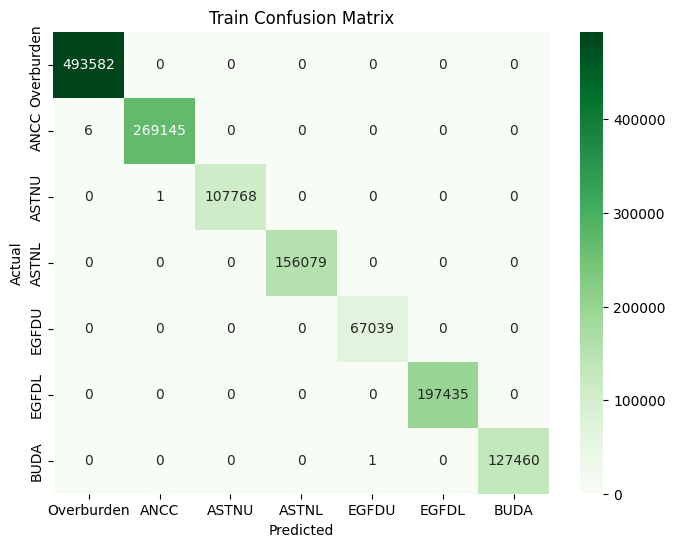

In [50]:
cm = confusion_matrix(df_v_train_pred_results['targets'], df_v_train_pred_results['preds'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.title('Train Confusion Matrix')
plt.show()

In [51]:
# Feature importances
model.eval()
n_repeats = 2
perm_mode = "joint" # 'joint' or 'timestep'

if VALIDATION:
    eval_loader = val_loader
else:
    eval_loader = train_loader

# Get baseline measure
with torch.no_grad():
    baseline_loss = 0
    total_samples = 0

    for _, X_batch, y_batch in eval_loader:
        X_batch, y_batch = (X_batch.to(device),y_batch.to(device))
        logits = model(X_batch)
        baseline = entropy_loss(logits.view(-1, logits.size(-1)), y_batch.view(-1))
        baseline_loss += baseline.item() * y_batch.numel()
        total_samples += y_batch.numel()
    total_baseline_loss = baseline_loss / total_samples

print(f"Baseline Loss: {total_baseline_loss:.4f}")


with torch.no_grad():
    repeat_losses = torch.zeros((len(feats_v), n_repeats), device=device)

    for _, X_batch, y_batch in eval_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        batch_size = X_batch.shape[0]
        n_samples = y_batch.numel()

        X_batch_permuted = torch.empty_like(X_batch)

        for f in range(len(feats_v)):

            for r in range(n_repeats):
                X_batch_permuted.copy_(X_batch)

                # jointly shuffle all timesteps of feature f with the ones on another sample
                if perm_mode == "joint":
                    idx = torch.randperm(batch_size, device=device)
                    X_batch_permuted[:, :, f] = X_batch[idx, :, f]

                # shuffle current feature independently at every timestep
                elif perm_mode == "timestep":
                    idx = torch.stack([torch.randperm(batch_size, device=device) for _ in range(WIN_V)], dim=0)  # (WIN_V,batch_size)
                    rows = idx.T          # (batch_size,WIN_V)
                    cols = torch.arange(WIN_V, device=device)
                    X_batch_permuted[:, :, f] = X_batch[rows, cols, f]

                logits = model(X_batch_permuted)
                loss_val = entropy_loss(logits.view(-1, logits.size(-1)), y_batch.view(-1))

                repeat_losses[f, r] += loss_val * n_samples

    total_samples = len(val_loader.dataset) * y_batch.shape[1]
    repeat_losses /= total_samples

    importance_array = (repeat_losses.mean(dim=1) - total_baseline_loss).cpu().numpy()

sorted_idx = np.argsort(importance_array)[::-1]


print(f"{'Rank':<6} {'Feature':<30} {'Importance':>12}")
print("=" * 50)
for rank, idx in enumerate(sorted_idx, 1):
    print(f"{rank:<6} {feats_v[idx]:<30} {importance_array[idx]:>12.8f}")

Baseline Loss: 0.0055
Rank   Feature                          Importance
1      GR_slope_200                     0.12023018
2      GR_var_200                       0.07745790
3      GR_slope_350                     0.07502035
4      dTVT                             0.05941886
5      GR_var_120                       0.05731711
6      GR_range_350                     0.04975902
7      GR_min_350                       0.04686727
8      GR_diff_GR_p05_350               0.04493590
9      TVT                              0.04146209
10     GR_var_70                        0.02738449
11     GR_p95_350                       0.02026554
12     GR_slope_120                     0.01890487
13     GR_median_350                    0.01778925
14     GR_diff_GR_p25_350               0.01714945
15     GR_skew_350                      0.01634762
16     GR_diff_GR_p95_350               0.01499695
17     GR_std_200                       0.01261680
18     GR_range_200                     0.01044565
19     GR

In [52]:
# load model
typelayer_model = torch.load(working_folder_path + "typelayer_model.pth", weights_only=False)
typelayer_model.eval()

TypeLayerLSTM(
  (lstm1): LSTM(129, 120, batch_first=True, bidirectional=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=240, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=7, bias=True)
  )
)

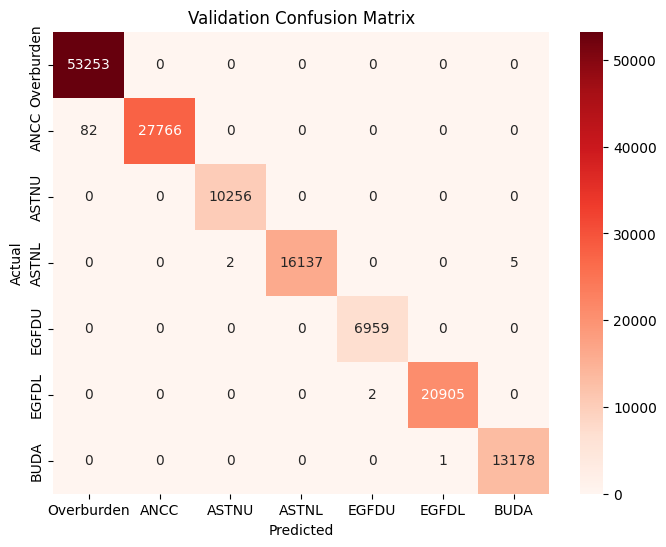

In [53]:
if VALIDATION:
    generate_confusion_matrix(df_v_val_pred_results, 'targets', 'preds', labels, 'Validation', 'Reds')

In [54]:
df_v_train = df_v_train[['id', 'wellname','GR', 'TVT', 'Geology', 'geology_index']]
if VALIDATION:
    df_v_val = df_v_val[['id', 'wellname','GR', 'TVT', 'Geology', 'geology_index']]
    df_v_val = df_v_val.merge(df_v_val_pred_results, on='id', how='left')

Sequence log prob: -1510.11
Sequence log prob: -3017.07
Sequence log prob: -1460.1
Sequence log prob: -1838.93
Sequence log prob: -1200.89
Sequence log prob: -1550.79
Sequence log prob: -1779.78
Sequence log prob: -1494.38
Sequence log prob: -1405.39
Sequence log prob: -1799.9
Sequence log prob: -830.17
Sequence log prob: -1648.3
Sequence log prob: -840.18
Sequence log prob: -1425.44
Sequence log prob: -1861.7
Sequence log prob: -2038.33
Sequence log prob: -1480.57
Sequence log prob: -1631.89
Sequence log prob: -1209.22
Sequence log prob: -932.19
Sequence log prob: -1040.13
Sequence log prob: -1425.41
Sequence log prob: -1540.07
Sequence log prob: -1352.39
Sequence log prob: -1657.98
Sequence log prob: -1710.22
Sequence log prob: -840.18
Sequence log prob: -1299.2
Sequence log prob: -1918.64
Sequence log prob: -1105.73
Sequence log prob: -840.18
Sequence log prob: -3026.28
Sequence log prob: -1936.72
Sequence log prob: -1518.77
Sequence log prob: -2385.41
Sequence log prob: -1854.7
Seq

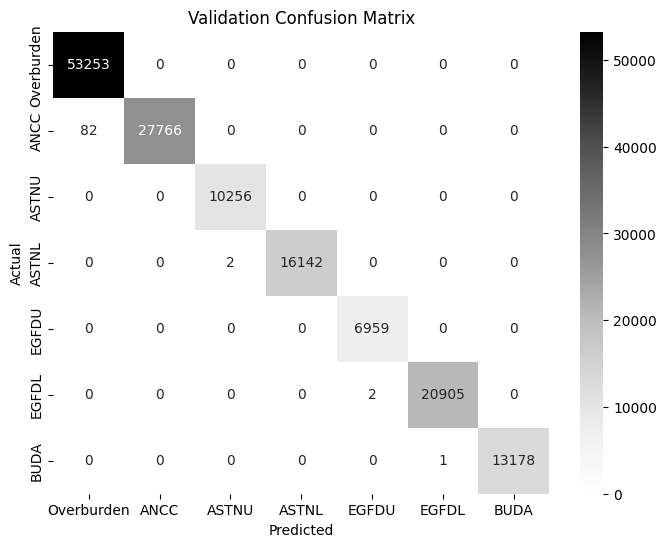

In [55]:
if VALIDATION:
    df_v_val = clean_layerlabel_hmm(df_v_val, 'preds')
    generate_confusion_matrix(df_v_val, 'targets', 'layer', labels, 'Validation', 'Grays')

In [56]:
if VALIDATION:
    val_accuracy = accuracy_score(df_v_val['targets'], df_v_val['layer'])
    print(val_accuracy)

0.9994143228360238


#### 2nd Training Preprocessing

In this phase we use the information we obtained about the layers from the Type Layer model and we know summarize the per layer characteristics of each well.

Actions are two-fold:

1. On one hand we extend the information on the typewell so that the TVT range existing on the horizontal well is fully covered. If this happens only on the edge layers we simply take the mean from the edge points and extend it for the necessary TVT range. If it happens in the middle we do hierarchical clustering with the train wells to check which wells have the most similar characteristics to the target well and fill the missing info with the info of one of those wells.

2. Secondly, we fill additional TVT steps on the typewell with a smaller degree of granularity, the GR values are filled with a definable level of noise, we can define the z-score on the function.



In [57]:
print("TVT to TVD differences for train set")
get_TVT_to_TVD_diffs(df_h_train, 5)

if VALIDATION:
    print("TVT to TVD differences for validation set")
    get_TVT_to_TVD_diffs(df_h_val, 5)

TVT to TVD differences for train set
TVT diffs:          wellname       TVD       TVT  TVT_diff
2087120  708caea9  10548.22  11055.10    506.88
2573128  8995c945  10512.74  11015.68    502.94
1958580  6767c111  10571.81  11071.71    499.90
828531   2bff06cf  10597.62  11018.08    420.46
4080938  d0cb63ae  10626.66  11044.69    418.03
TVT to TVD differences for validation set
TVT diffs:          wellname       TVD       TVT  TVT_diff
4913113  f6d009f4  10568.46  11085.22    516.76
5006302  fb73b13a  10314.96  10808.40    493.44
4880565  f5859199  11852.08  12241.42    389.34
5085833  ff8bb73a  10835.90  11212.00    376.10
4709807  ef04658e  10464.16  10793.67    329.51


In [58]:
df_v_train.rename(columns={'geology_index': 'layer'}, inplace=True)

# Create a summary table of GR and TVT stats for each layer per well
df_v_train_summary = summarize_typewells(df_v_train, layer_nbs)

print(df_v_train_summary.head())

   wellname  layer  first_TVT  last_TVT  depth  GR_mean  GR_median  GR_var  \
0  000d7d20      0   11223.95  11372.95  149.0   109.23     106.64  178.14   
1  000d7d20      1   11373.45  11546.95  173.5    86.09      87.06  281.97   
2  000d7d20      2   11547.45  11574.95   27.5    79.87      78.39  207.24   
3  000d7d20      3   11575.45  11647.95   72.5    50.77      48.10  226.10   
4  000d7d20      4   11648.45  11682.95   34.5    62.63      63.13   55.02   

   GR_min  GR_max  GR_p05  GR_p95  GR_skew  GR_slope  GR_IQR  IGR_mean  \
0   88.68  158.18   92.07  133.74     1.07     -0.06   17.59      0.40   
1   48.29  118.62   58.72  108.58    -0.20      0.13   28.35      0.55   
2   59.13  121.80   62.08  109.52     1.05      0.42   17.64      0.37   
3   30.12  123.18   33.72   70.38     1.91      0.03   17.00      0.43   
4   48.64   80.78   50.25   73.19    -0.10     -0.08   12.54      0.53   

   IGR_median  IGR_var  IGR_skew  IGR_IQR  
0        0.35     0.08      0.62     0.43 

In [59]:
df_train_summary_agg = aggregate_summary_typewells(df_v_train_summary, df_h_train)
print(df_train_summary_agg.head())

   wellname  v_start_layer  v_end_layer  v_start_TVT  v_end_TVT  h_start_TVT  \
0  000d7d20              0            6     11223.95   11871.45     11236.02   
1  00bbac68              0            6     11394.45   12366.95     11406.63   
2  00e12e8b              0            6     10593.95   11871.45     10606.18   
3  015fe0d2              0            6     11734.95   12366.95     11747.26   
4  01869cd4              0            6     11345.95   11871.45     11358.27   

   h_end_TVT  v_start_clipped  v_end_clipped  
0   11759.12            False          False  
1   12243.01            False          False  
2   11619.64            False          False  
3   12274.53            False          False  
4   11770.75            False          False  


In [60]:
# Pivot train summary data
df_v_train_summary_pivot = pivot_agg_summary_typewells(df_v_train_summary, df_train_summary_agg)
print(df_v_train_summary_pivot.head())

   wellname  first_TVT_0  first_TVT_1  first_TVT_2  first_TVT_3  first_TVT_4  \
0  000d7d20     11223.95     11373.45     11547.45     11575.45     11648.45   
1  00bbac68     11394.45     11855.45     11999.95     12032.45     12147.95   
2  00e12e8b     10593.95     11373.45     11547.45     11575.45     11648.45   
3  015fe0d2     11734.95     11855.45     11999.95     12032.45     12147.95   
4  01869cd4     11345.95     11373.45     11547.45     11575.45     11648.45   

   first_TVT_5  first_TVT_6  last_TVT_0  last_TVT_1  last_TVT_2  last_TVT_3  \
0     11683.45     11823.95    11372.95    11546.95    11574.95    11647.95   
1     12184.45     12321.95    11854.95    11999.45    12031.95    12147.45   
2     11683.45     11823.95    11372.95    11546.95    11574.95    11647.95   
3     12184.45     12321.95    11854.95    11999.45    12031.95    12147.45   
4     11683.45     11823.95    11372.95    11546.95    11574.95    11647.95   

   last_TVT_4  last_TVT_5  last_TVT_6  depth

In [61]:
df_v_train = fix_typewell_tvtgr_ranges(df_v_train, df_v_train, df_v_train_summary_pivot, df_v_train_summary_pivot, STEP1, STEP2)

clipped_0_layer: ['02e7fe5a', '10b89021', '3417285d', '3c3dbcbc', '6ae68655', '7993a768', 'bc4381e2']
clipped_mid_upper_layer: []
clipped_mid_lower_layer: ['0bbf5e67', '2cee0cba']
clipped_6_layer: []
Current well: 000d7d20
Fixing TVT for welltype 000d7d20.
Original length: 1296. New length: 2591.
Current well: 00bbac68
Fixing TVT for welltype 00bbac68.
Original length: 1946. New length: 3891.
Current well: 00e12e8b
Fixing TVT for welltype 00e12e8b.
Original length: 2556. New length: 5111.
Current well: 015fe0d2
Fixing TVT for welltype 015fe0d2.
Original length: 1265. New length: 2529.
Current well: 01869cd4
Fixing TVT for welltype 01869cd4.
Original length: 1052. New length: 2103.
Current well: 01982c1d
Fixing TVT for welltype 01982c1d.
Original length: 2213. New length: 4425.
Current well: 028d7b28
Fixing TVT for welltype 028d7b28.
Original length: 1774. New length: 3547.
Current well: 02e7fe5a
Fixing clipped layer 0
Fixing TVT for welltype 02e7fe5a.
Original length: 1433. New length:

In [62]:
if VALIDATION:
    df_v_val_summary = summarize_typewells(df_v_val, layer_nbs)

In [63]:
if VALIDATION:
    df_val_summary_agg = aggregate_summary_typewells(df_v_val_summary, df_h_val, train=False)

In [64]:
if VALIDATION:
    # Pivot val summary data
    df_v_val_summary_pivot = pivot_agg_summary_typewells(df_v_val_summary, df_val_summary_agg)

In [65]:
if VALIDATION:
    df_v_val = fix_typewell_tvtgr_ranges(df_v_val, df_v_train, df_v_val_summary_pivot, df_v_train_summary_pivot, STEP1, STEP2)

clipped_0_layer: ['ecdab904', 'f021b650', 'f49fdea3', 'f88ddb26']
clipped_mid_upper_layer: []
clipped_mid_lower_layer: []
clipped_6_layer: ['ea0b99b7', 'ea3a0e38', 'ea41324e', 'eabc711b', 'eac10e86', 'eafb863e', 'eb06a4e7', 'eb640a35', 'eb934281', 'eba6605e', 'ebe69318', 'ec0d597b', 'ec13af42', 'ecdab904', 'ecdaf714', 'ed6436d6', 'ed6e6e54', 'edf885a3', 'ee0300f7', 'ee288beb', 'ee4aecac', 'eeda36f5', 'eeed308d', 'ef04658e', 'ef8e3ed0', 'efde6ac3', 'efe96181', 'f0188a48', 'f021b650', 'f03f10fe', 'f053a1b9', 'f074d277', 'f07d7037', 'f08774c3', 'f140c2fa', 'f16e25e3', 'f2d4c8c9', 'f321a31c', 'f40cd091', 'f439a621', 'f49fdea3', 'f4d12d23', 'f56d3ace', 'f5859199', 'f5d8aab6', 'f631da6e', 'f6824bb0', 'f6bc699b', 'f6d009f4', 'f72b268f', 'f8662c22', 'f88ddb26', 'f8afa78a', 'f8f59188', 'f9fc81aa', 'fa16d114', 'fa31da94', 'fa667be2', 'fae0c593', 'fb03ae90', 'fb0904bd', 'fb3848a1', 'fb73b13a', 'fba7683c', 'fbd68d27', 'fc03f21f', 'fc0d20b2', 'fcfcc902', 'fd3b4faa', 'fd710aea', 'fd8f77fa', 'fde20ec

#### Horizontal TVT Training

This training section does not follow a conventional training pattern in the sense of we training a model, here no model is trained to use on inference. This is because in this method we make the prediction step by step incrementally and having the information of the prediction of the previous step. So instead we already run the prediction algorithm and compare against the True TVT from the files and visually inspect the evaluation metrics we get, so we're training in the sense of verifying how reliable is our prediction approach.

The initial set is split into train and validation sets.

- For the train set we run the prediction using the true TVT information from the previous row as a stepstone, so we don't accumulate errors from the previous steps predictions. We also use the original layer typewell information.

- For the val set we run the prediction using the predicted TVT information from the previous row as a stepstone, so we accumulate errors from the previous steps like it happens during the actual prediction step. We also use the predicted layer typewell information from the previous training section of the script.

In [66]:
# List ref ids per well
df_tvt_ref_train = generate_tvt_ref_df(df_h_train)

# Add full tvt features
df_h_train = add_full_tvt_features_loop(df_h_train, df_v_train, df_tvt_ref_train)

if VALIDATION:
    df_tvt_ref_val = generate_tvt_ref_df(df_h_val)
    df_h_val = add_full_tvt_features_loop(df_h_val, df_v_val, df_tvt_ref_val)

In [67]:
df_train_results = predict_tvt(df_h_train, df_v_train, df_tvt_ref_train, mode='train', wells_limit=3)

Well: 000d7d20
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 0}
XGB Regression R2: 1.0 | XGB Regression RMSE: 0.5611 | 
KNN Best Parameters: {'algorithm': 'auto', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
KNN Regression R2: 1.0 | KNN Regression RMSE: 0.0 | 
Well: 000d7d20 | Prediction R2: 1.00 | Prediction RMSE: 0.119 | 

Well: 00bbac68
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0.001, 'reg_lambda': 0.1}
XGB Regression R2: 1.0 | XGB Regression RMSE: 0.7243 | 
KNN Best Parameters: {'algorithm': 'auto', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 2, 'p': 3, 'weights': 'distance'}
KNN Regression R2: 1.0 | KNN Regression RMSE: 0.0 | 
Well: 00bbac68 | Prediction R2: 1.00 | Prediction RMSE: 0.158 | 

Well: 00e12e8b
XGB Regressio

In [68]:
if VALIDATION:
    df_val_results = predict_tvt(df_h_val, df_v_val, df_tvt_ref_val, mode='val', wells_limit=3)

Well: ea0b99b7
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 0}
XGB Regression R2: 1.0 | XGB Regression RMSE: 0.4825 | 
KNN Best Parameters: {'algorithm': 'auto', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 2, 'p': 3, 'weights': 'distance'}
KNN Regression R2: 1.0 | KNN Regression RMSE: 0.0 | 
Well: ea0b99b7 | Prediction R2: -3.36 | Prediction RMSE: 13.089 | 

Well: ea3a0e38
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 0}
XGB Regression R2: 1.0 | XGB Regression RMSE: 0.6938 | 
KNN Best Parameters: {'algorithm': 'auto', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 2, 'p': 3, 'weights': 'distance'}
KNN Regression R2: 1.0 | KNN Regression RMSE: 0.0 | 
Well: ea3a0e38 | Prediction R2: -0.08 | Prediction RMSE: 8.841 | 

Well: ea41324e
XGB Regression Bes

# Main (Inference)

#### 1st Prediction Preprocessing

In [69]:
TEST_FOLDER = 'test'

In [70]:
# # Ingestion
df_h_test, df_v_test = preprocess_files(input_folder_path, TEST_FOLDER, STEP1, LOOK_AHEAD, geo_encoder, geo_decoder)

No well files missing.


#### Typewell Layer Prediction


In [71]:
test_dataset = TypeLayerDataset(df_v_test, feats_v, WIN_V, scaler_v, train=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_V, collate_fn=DrillCollator(train=False))

In [72]:
# Inference of typewell layers
df_test_pred_results = predict_typelayer(typelayer_model, test_loader)

In [73]:
df_v_test = df_v_test[['id', 'wellname','GR', 'TVT']]
df_v_test = df_v_test.merge(df_test_pred_results, on='id', how='left')

In [74]:
# Apply Hidden Markov Chains model to smoothen the layer predictions
df_v_test = clean_layerlabel_hmm(df_v_test, 'preds')

Sequence log prob: -1082.48
Sequence log prob: -1622.56
Sequence log prob: -2128.72


#### 2nd Prediction Preprocessing

In [75]:
# Creating reference summary from entire train set
df_v_train = df_v[['id', 'wellname','GR', 'TVT', 'geology_index']]
df_v_train.rename(columns={'geology_index': 'layer'}, inplace=True)
df_h_train = df_h[['wellname','TVD', 'TVT']]

# Create a summary table of GR and TVT stats for each layer per well
df_v_train_summary = summarize_typewells(df_v_train, layer_nbs)
df_train_summary_agg = aggregate_summary_typewells(df_v_train_summary, df_h_train)
df_v_train_summary_pivot = pivot_agg_summary_typewells(df_v_train_summary, df_train_summary_agg)

In [76]:
# Create a summary table of GR and TVT stats for each layer per well
df_v_test_summary = summarize_typewells(df_v_test, layer_nbs)

In [77]:
df_test_summary_agg = aggregate_summary_typewells(df_v_test_summary, df_h_test, train=False)

In [78]:
# Pivot test summary data
df_v_test_summary_pivot = pivot_agg_summary_typewells(df_v_test_summary, df_test_summary_agg)

In [79]:
df_v_test = fix_typewell_tvtgr_ranges(df_v_test, df_v_train, df_v_test_summary_pivot, df_v_train_summary_pivot, STEP1, STEP2)

clipped_0_layer: []
clipped_mid_upper_layer: []
clipped_mid_lower_layer: []
clipped_6_layer: ['000d7d20', '00bbac68', '00e12e8b']
Current well: 000d7d20
Fixing clipped layer 6
Fixing TVT for welltype 000d7d20.
Original length: 1678. New length: 4119.
Current well: 00bbac68
Fixing clipped layer 6
Fixing TVT for welltype 00bbac68.
Original length: 2252. New length: 5115.
Current well: 00e12e8b
Fixing clipped layer 6
Fixing TVT for welltype 00e12e8b.
Original length: 2794. New length: 6063.


#### Horizontal TVT Prediction

In [80]:
# List ref ids per well based on TVT_input
df_tvt_ref_test = generate_tvt_ref_df(df_h_test)

In [81]:
df_h_test = add_full_tvt_features_loop(df_h_test, df_v_test, df_TVT_ref=df_tvt_ref_test)

In [82]:
df_results= predict_tvt(df_h_test, df_v_test, df_tvt_ref_test)

Well: 000d7d20
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 0}
XGB Regression R2: 1.0 | XGB Regression RMSE: 0.5611 | 
KNN Best Parameters: {'algorithm': 'auto', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
KNN Regression R2: 1.0 | KNN Regression RMSE: 0.0 | 
Well: 00bbac68
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0.001, 'reg_lambda': 0.1}
XGB Regression R2: 1.0 | XGB Regression RMSE: 0.7243 | 
KNN Best Parameters: {'algorithm': 'auto', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 2, 'p': 3, 'weights': 'distance'}
KNN Regression R2: 1.0 | KNN Regression RMSE: 0.0 | 
Well: 00e12e8b
XGB Regression Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'random_state': 42, 'reg_alpha': 0.001, 'reg_lambda

In [83]:
df_test = prepare_results(df_results, df_tvt_ref_test, train=False)
df_test.to_csv('submission.csv', index=False)

# Execution End Timing

In [84]:
end_time = time.time()

elapsed = end_time - start_time

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = elapsed % 60

print(f"Execution time: {hours}h {minutes}m {seconds:.2f}s")

Execution time: 3h 56m 3.91s
